<a href="https://colab.research.google.com/github/ButenkoYuliia/Python-for-DA-Modul-Task/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os
import pandas as pd

# --- Schritt 1: Entpacken der Datei (aus b086aff8) ---
zip_file_path = '/content/dataset (1).zip'
extract_dir = '/content/unzipped_data'

# Erstellen Sie das Extraktionsverzeichnis, falls es nicht existiert
os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"'{(zip_file_path)}' erfolgreich entpackt nach '{(extract_dir)}'")
except FileNotFoundError:
    print(f"Fehler: Zip-Datei nicht gefunden unter '{(zip_file_path)}'. Bitte stellen Sie sicher, dass sie hochgeladen wurde.")
except Exception as e:
    print(f"Ein Fehler ist beim Entpacken aufgetreten: {e}")

# --- Schritt 2: Laden der Datensätze (aus a72b68b4) ---
base_dir = '/content/unzipped_data/13. Final project/'

countries_path = os.path.join(base_dir, 'countries.csv')
products_path = os.path.join(base_dir, 'products.csv')
events_path = os.path.join(base_dir, 'events.csv')

try:
    countries_df = pd.read_csv(countries_path)
    products_df = pd.read_csv(products_path)
    events_df = pd.read_csv(events_path)

    print("\nDataFrames erfolgreich geladen:")
    print(f"  countries_df: {countries_df.shape[0]} Zeilen, {countries_df.shape[1]} Spalten")
    print(f"  products_df: {products_df.shape[0]} Zeilen, {products_df.shape[1]} Spalten")
    print(f"  events_df: {events_df.shape[0]} Zeilen, {events_df.shape[1]} Spalten")

except FileNotFoundError as e:
    print(f"\nFehler beim Laden der Datei: {e}. Bitte stellen Sie sicher, dass die Dateien nach dem Entpacken im richtigen Pfad sind.")
    raise
except Exception as e:
    print(f"\nEin unerwarteter Fehler ist beim Laden der Daten aufgetreten: {e}")
    raise

# --- Schritt 3: Definition der Funktion check_missing_values (aus 0cd4de7a) ---
def check_missing_values(df, df_name):
    print(f"\n--- Fehlende Werte in {df_name} ---")
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0]

    if missing_data.empty:
        print("Keine fehlenden Werte gefunden.")
    else:
        missing_percentage = (missing_data / len(df)) * 100
        missing_table = pd.DataFrame({
            'Anzahl fehlender Werte': missing_data,
            'Prozentsatz fehlender Werte': missing_percentage
        })
        print(missing_table.sort_values(by='Prozentsatz fehlender Werte', ascending=False))

# --- Schritt 4: Behandeln fehlender Werte (aus 1ac10c3b) ---
print("\n--- Behandeln fehlender Werte ---")

# Überprüfen Sie anfängliche fehlende Werte
check_missing_values(countries_df, 'countries_df (initial)')
check_missing_values(products_df, 'products_df (initial)')
check_missing_values(events_df, 'events_df (initial)')


# countries_df: Zeilen mit fehlenden 'alpha-2', 'region' oder 'sub-region' löschen
initial_rows_countries = countries_df.shape[0]
countries_df.dropna(subset=['alpha-2', 'region', 'sub-region'], inplace=True)
print(f"{(initial_rows_countries - countries_df.shape[0])} Zeilen aus countries_df gelöscht aufgrund fehlender alpha-2, region oder sub-region.")

# products_df: Keine fehlenden Werte, daher keine Aktion für diesen DataFrame erforderlich.
print("products_df hat keine fehlenden Werte; keine Aktion durchgeführt.")

# events_df: Zeilen mit fehlendem 'Country Code' oder 'Units Sold' löschen
initial_rows_events = events_df.shape[0]
events_df.dropna(subset=['Country Code', 'Units Sold'], inplace=True)
print(f"{(initial_rows_events - events_df.shape[0])} Zeilen aus events_df gelöscht aufgrund fehlender 'Country Code' oder 'Units Sold'.")

# Überprüfen Sie fehlende Werte nach der Behandlung
print("\n--- Fehlende Werte nach der Behandlung ---")
check_missing_values(countries_df, 'countries_df (nach Behandlung)')
check_missing_values(products_df, 'products_df (nach Behandlung)')
check_missing_values(events_df, 'events_df (nach Behandlung)')

# --- Schritt 5: Datentypkonvertierungen (aus 0242747b) ---
print("\n--- Datentypkonvertierungen durchführen ---")

# Konvertieren Sie 'Order Date' und 'Ship Date' in events_df in Datetime-Objekte
events_df['Order Date'] = pd.to_datetime(events_df['Order Date'])
events_df['Ship Date'] = pd.to_datetime(events_df['Ship Date'])

print("'Order Date' und 'Ship Date' in events_df in Datetime konvertiert.")

# Überprüfen Sie die Datentypen nach der Konvertierung
print("\n--- Datentypen nach der Konvertierung (events_df) ---")
print(events_df.info())

'/content/dataset (1).zip' erfolgreich entpackt nach '/content/unzipped_data'

DataFrames erfolgreich geladen:
  countries_df: 249 Zeilen, 5 Spalten
  products_df: 12 Zeilen, 2 Spalten
  events_df: 1330 Zeilen, 10 Spalten

--- Behandeln fehlender Werte ---

--- Fehlende Werte in countries_df (initial) ---
            Anzahl fehlender Werte  Prozentsatz fehlender Werte
alpha-2                          1                     0.401606
region                           1                     0.401606
sub-region                       1                     0.401606

--- Fehlende Werte in products_df (initial) ---
Keine fehlenden Werte gefunden.

--- Fehlende Werte in events_df (initial) ---
              Anzahl fehlender Werte  Prozentsatz fehlender Werte
Country Code                      82                     6.165414
Units Sold                         2                     0.150376
2 Zeilen aus countries_df gelöscht aufgrund fehlender alpha-2, region oder sub-region.
products_df hat keine fe

In [ ]:
import zipfile
import os

zip_file_path = '/content/dataset (1).zip'
extract_dir = '/content/unzipped_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Successfully unzipped '{zip_file_path}' to '{extract_dir}'")

Successfully unzipped '/content/dataset (1).zip' to '/content/unzipped_data'


In [ ]:
# List the contents of the unzipped directory
print("Contents of the unzipped directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of the unzipped directory:


In [ ]:
import pandas as pd

# Define the base directory where the files were unzipped
base_dir = '/content/unzipped_data/13. Final project/'

# Define file paths
countries_path = os.path.join(base_dir, 'countries.csv')
products_path = os.path.join(base_dir, 'products.csv')
events_path = os.path.join(base_dir, 'events.csv')

# Load the datasets
try:
    countries_df = pd.read_csv(countries_path)
    products_df = pd.read_csv(products_path)
    events_df = pd.read_csv(events_path)

    print("DataFrames loaded successfully:")
    print(f"  countries_df: {countries_df.shape[0]} rows, {countries_df.shape[1]} columns")
    print(f"  products_df: {products_df.shape[0]} rows, {products_df.shape[1]} columns")
    print(f"  events_df: {events_df.shape[0]} rows, {events_df.shape[1]} columns")

except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure the files are in the correct path.")
except Exception as e:
    print(f"An unexpected error occurred while loading data: {e}")

DataFrames loaded successfully:
  countries_df: 249 rows, 5 columns
  products_df: 12 rows, 2 columns
  events_df: 1330 rows, 10 columns


In [ ]:
def check_missing_values(df, df_name):
    print(f"\n--- Missing Values in {df_name} ---")
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0]

    if missing_data.empty:
        print("No missing values found.")
    else:
        missing_percentage = (missing_data / len(df)) * 100
        missing_table = pd.DataFrame({
            'Missing Count': missing_data,
            'Missing Percentage': missing_percentage
        })
        print(missing_table.sort_values(by='Missing Percentage', ascending=False))

# Check missing values for each DataFrame
check_missing_values(countries_df, 'countries_df')
check_missing_values(products_df, 'products_df')
check_missing_values(events_df, 'events_df')


--- Missing Values in countries_df ---
No missing values found.

--- Missing Values in products_df ---
No missing values found.

--- Missing Values in events_df ---
No missing values found.


In [ ]:
# --- Handle Missing Values ---

print("\n--- Handling Missing Values ---")

# countries_df: Drop rows with missing 'alpha-2', 'region', or 'sub-region'
initial_rows_countries = countries_df.shape[0]
countries_df.dropna(subset=['alpha-2', 'region', 'sub-region'], inplace=True)
print(f"Dropped {initial_rows_countries - countries_df.shape[0]} rows from countries_df due to missing alpha-2, region, or sub-region.")

# products_df: No missing values, so no action needed for this dataframe.
print("products_df has no missing values; no action taken.")

# events_df: Drop rows with missing 'Country Code' or 'Units Sold'
initial_rows_events = events_df.shape[0]
events_df.dropna(subset=['Country Code', 'Units Sold'], inplace=True)
print(f"Dropped {initial_rows_events - events_df.shape[0]} rows from events_df due to missing 'Country Code' or 'Units Sold'.")

# Verify missing values after handling
print("\n--- Missing Values After Handling ---")
check_missing_values(countries_df, 'countries_df')
check_missing_values(products_df, 'products_df')
check_missing_values(events_df, 'events_df')


--- Handling Missing Values ---
Dropped 2 rows from countries_df due to missing alpha-2, region, or sub-region.
products_df has no missing values; no action taken.
Dropped 84 rows from events_df due to missing 'Country Code' or 'Units Sold'.

--- Missing Values After Handling ---

--- Missing Values in countries_df ---
No missing values found.

--- Missing Values in products_df ---
No missing values found.

--- Missing Values in events_df ---
No missing values found.


In [ ]:
# --- Data Type Conversions ---

print("\n--- Performing Data Type Conversions ---")

# Convert 'Order Date' and 'Ship Date' in events_df to datetime objects
events_df['Order Date'] = pd.to_datetime(events_df['Order Date'])
events_df['Ship Date'] = pd.to_datetime(events_df['Ship Date'])

print("Converted 'Order Date' and 'Ship Date' in events_df to datetime.")

# Verify data types after conversion
print("\n--- Data Types After Conversion (events_df) ---")
print(events_df.info())


--- Performing Data Type Conversions ---
Converted 'Order Date' and 'Ship Date' in events_df to datetime.

--- Data Types After Conversion (events_df) ---
<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   int64         
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   int64         
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   float64       
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 107.1+ KB
None


In [ ]:
# --- Check for Duplicates ---

print("\n--- Checking for Duplicates ---")

def check_duplicates(df, df_name):
    print(f"\nDuplicates in {df_name}:")
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        print("No exact duplicate rows found.")
    else:
        print(f"Found {len(duplicates)} exact duplicate rows.")
        print(duplicates.head())

# Check for exact duplicates in each DataFrame
check_duplicates(countries_df, 'countries_df')
check_duplicates(products_df, 'products_df')
check_duplicates(events_df, 'events_df')


--- Checking for Duplicates ---

Duplicates in countries_df:
No exact duplicate rows found.

Duplicates in products_df:
No exact duplicate rows found.

Duplicates in events_df:
No exact duplicate rows found.


In [ ]:
# --- Check for Anomalies ---

print("\n--- Checking for Anomalies ---")

# --- Anomalies in countries_df ---
print("\nAnomalies in countries_df:")
# Check for non-standard entries in categorical columns (e.g., unexpected regions)
for col in ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']:
    print(f"Unique values for '{col}': {countries_df[col].nunique()} (showing first 10 if many)")
    print(countries_df[col].value_counts().head(10))
    print("\n")

# --- Anomalies in products_df ---
print("\nAnomalies in products_df:")
# Check for unusual product types
print(f"Unique values for 'item_type': {products_df['item_type'].nunique()} (showing all)")
print(products_df['item_type'].value_counts())
print("\n")

# --- Anomalies in events_df ---
print("\nAnomalies in events_df:")

# 1. Temporal Anomalies (Order Date and Ship Date)
print("Temporal Anomalies (events_df):")
# Check if Ship Date is ever before Order Date
ship_before_order = events_df[events_df['Ship Date'] < events_df['Order Date']]
if not ship_before_order.empty:
    print(f"  Found {len(ship_before_order)} rows where Ship Date is before Order Date.")
    print(ship_before_order[['Order Date', 'Ship Date']].head())
else:
    print("  No instances where Ship Date is before Order Date.")

# Check for extreme dates (e.g., dates too far in the past or future)
print(f"  Order Date range: {events_df['Order Date'].min()} to {events_df['Order Date'].max()}")
print(f"  Ship Date range: {events_df['Ship Date'].min()} to {events_df['Ship Date'].max()}")
print("\n")

# 2. Numerical Anomalies (Units Sold, Unit Price, Unit Cost)
print("Numerical Anomalies (events_df):")
for col in ['Units Sold', 'Unit Price', 'Unit Cost']:
    print(f"  Descriptive statistics for '{col}':")
    print(events_df[col].describe())

    # Check for non-positive values if applicable (e.g., Units Sold should be > 0)
    if (events_df[col] < 0).any():
        print(f"  WARNING: Found negative values in '{col}'.")
        print(events_df[events_df[col] < 0].head())
    elif col == 'Units Sold' and (events_df[col] == 0).any():
        print(f"  WARNING: Found zero values in '{col}'. This might be an anomaly.")
        print(events_df[events_df[col] == 0].head())
    print("\n")

# Check for 'Unit Cost' > 'Unit Price' (potential loss)
profit_loss_anomalies = events_df[events_df['Unit Cost'] > events_df['Unit Price']]
if not profit_loss_anomalies.empty:
    print(f"  Found {len(profit_loss_anomalies)} rows where Unit Cost is greater than Unit Price.")
    print(profit_loss_anomalies[['Unit Price', 'Unit Cost']].head())
else:
    print("  No instances where Unit Cost is greater than Unit Price.")



--- Checking for Anomalies ---

Anomalies in countries_df:
Unique values for 'name': 247 (showing first 10 if many)
name
Afghanistan            1
Åland Islands          1
Albania                1
Algeria                1
American Samoa         1
Andorra                1
Angola                 1
Anguilla               1
Antigua and Barbuda    1
Argentina              1
Name: count, dtype: int64


Unique values for 'alpha-2': 247 (showing first 10 if many)
alpha-2
AF    1
AX    1
AL    1
DZ    1
AS    1
AD    1
AO    1
AI    1
AG    1
AR    1
Name: count, dtype: int64


Unique values for 'alpha-3': 247 (showing first 10 if many)
alpha-3
AFG    1
ALA    1
ALB    1
DZA    1
ASM    1
AND    1
AGO    1
AIA    1
ATG    1
ARG    1
Name: count, dtype: int64


Unique values for 'region': 5 (showing first 10 if many)
region
Africa      59
Americas    57
Asia        51
Europe      51
Oceania     29
Name: count, dtype: int64


Unique values for 'sub-region': 17 (showing first 10 if many)
sub-regio

In [ ]:
# --- Check for Anomalies ---

print("\n--- Checking for Anomalies ---")

# --- Anomalies in countries_df ---
print("\nAnomalies in countries_df:")
# Check for non-standard entries in categorical columns (e.g., unexpected regions)
for col in ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']:
    print(f"Unique values for '{col}': {countries_df[col].nunique()} (showing first 10 if many)")
    print(countries_df[col].value_counts().head(10))
    print("\n")

# --- Anomalies in products_df ---
print("\nAnomalies in products_df:")
# Check for unusual product types
print(f"Unique values for 'item_type': {products_df['item_type'].nunique()} (showing all)")
print(products_df['item_type'].value_counts())
print("\n")

# --- Anomalies in events_df ---
print("\nAnomalies in events_df:")

# 1. Temporal Anomalies (Order Date and Ship Date)
print("Temporal Anomalies (events_df):")
# Check if Ship Date is ever before Order Date
ship_before_order = events_df[events_df['Ship Date'] < events_df['Order Date']]
if not ship_before_order.empty:
    print(f"  Found {len(ship_before_order)} rows where Ship Date is before Order Date.")
    print(ship_before_order[['Order Date', 'Ship Date']].head())
else:
    print("  No instances where Ship Date is before Order Date.")

# Check for extreme dates (e.g., dates too far in the past or future)
print(f"  Order Date range: {events_df['Order Date'].min()} to {events_df['Order Date'].max()}")
print(f"  Ship Date range: {events_df['Ship Date'].min()} to {events_df['Ship Date'].max()}")
print("\n")

# 2. Numerical Anomalies (Units Sold, Unit Price, Unit Cost)
print("Numerical Anomalies (events_df):")
for col in ['Units Sold', 'Unit Price', 'Unit Cost']:
    print(f"  Descriptive statistics for '{col}':")
    print(events_df[col].describe())

    # Check for non-positive values if applicable (e.g., Units Sold should be > 0)
    if (events_df[col] < 0).any():
        print(f"  WARNING: Found negative values in '{col}'.")
        print(events_df[events_df[col] < 0].head())
    elif col == 'Units Sold' and (events_df[col] == 0).any():
        print(f"  WARNING: Found zero values in '{col}'. This might be an anomaly.")
        print(events_df[events_df[col] == 0].head())
    print("\n")

# Check for 'Unit Cost' > 'Unit Price' (potential loss)
profit_loss_anomalies = events_df[events_df['Unit Cost'] > events_df['Unit Price']]
if not profit_loss_anomalies.empty:
    print(f"  Found {len(profit_loss_anomalies)} rows where Unit Cost is greater than Unit Price.")
    print(profit_loss_anomalies[['Unit Price', 'Unit Cost']].head())
else:
    print("  No instances where Unit Cost is greater than Unit Price.")



--- Checking for Anomalies ---

Anomalies in countries_df:
Unique values for 'name': 247 (showing first 10 if many)
name
Afghanistan            1
Åland Islands          1
Albania                1
Algeria                1
American Samoa         1
Andorra                1
Angola                 1
Anguilla               1
Antigua and Barbuda    1
Argentina              1
Name: count, dtype: int64


Unique values for 'alpha-2': 247 (showing first 10 if many)
alpha-2
AF    1
AX    1
AL    1
DZ    1
AS    1
AD    1
AO    1
AI    1
AG    1
AR    1
Name: count, dtype: int64


Unique values for 'alpha-3': 247 (showing first 10 if many)
alpha-3
AFG    1
ALA    1
ALB    1
DZA    1
ASM    1
AND    1
AGO    1
AIA    1
ATG    1
ARG    1
Name: count, dtype: int64


Unique values for 'region': 5 (showing first 10 if many)
region
Africa      59
Americas    57
Asia        51
Europe      51
Oceania     29
Name: count, dtype: int64


Unique values for 'sub-region': 17 (showing first 10 if many)
sub-regio

In [ ]:
# --- Check for Anomalies ---

print("\n--- Checking for Anomalies ---")

# --- Anomalies in countries_df ---
print("\nAnomalies in countries_df:")
# Check for non-standard entries in categorical columns (e.g., unexpected regions)
for col in ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']:
    print(f"Unique values for '{col}': {countries_df[col].nunique()} (showing first 10 if many)")
    print(countries_df[col].value_counts().head(10))
    print("\n")

# --- Anomalies in products_df ---
print("\nAnomalies in products_df:")
# Check for unusual product types
print(f"Unique values for 'item_type': {products_df['item_type'].nunique()} (showing all)")
print(products_df['item_type'].value_counts())
print("\n")

# --- Anomalies in events_df ---
print("\nAnomalies in events_df:")

# 1. Temporal Anomalies (Order Date and Ship Date)
print("Temporal Anomalies (events_df):")
# Check if Ship Date is ever before Order Date
ship_before_order = events_df[events_df['Ship Date'] < events_df['Order Date']]
if not ship_before_order.empty:
    print(f"  Found {len(ship_before_order)} rows where Ship Date is before Order Date.")
    print(ship_before_order[['Order Date', 'Ship Date']].head())
else:
    print("  No instances where Ship Date is before Order Date.")

# Check for extreme dates (e.g., dates too far in the past or future)
print(f"  Order Date range: {events_df['Order Date'].min()} to {events_df['Order Date'].max()}")
print(f"  Ship Date range: {events_df['Ship Date'].min()} to {events_df['Ship Date'].max()}")
print("\n")

# 2. Numerical Anomalies (Units Sold, Unit Price, Unit Cost)
print("Numerical Anomalies (events_df):")
for col in ['Units Sold', 'Unit Price', 'Unit Cost']:
    print(f"  Descriptive statistics for '{col}':")
    print(events_df[col].describe())

    # Check for non-positive values if applicable (e.g., Units Sold should be > 0)
    if (events_df[col] < 0).any():
        print(f"  WARNING: Found negative values in '{col}'.")
        print(events_df[events_df[col] < 0].head())
    elif col == 'Units Sold' and (events_df[col] == 0).any():
        print(f"  WARNING: Found zero values in '{col}'. This might be an anomaly.")
        print(events_df[events_df[col] == 0].head())
    print("\n")

# Check for 'Unit Cost' > 'Unit Price' (potential loss)
profit_loss_anomalies = events_df[events_df['Unit Cost'] > events_df['Unit Price']]
if not profit_loss_anomalies.empty:
    print(f"  Found {len(profit_loss_anomalies)} rows where Unit Cost is greater than Unit Price.")
    print(profit_loss_anomalies[['Unit Price', 'Unit Cost']].head())
else:
    print("  No instances where Unit Cost is greater than Unit Price.")



--- Checking for Anomalies ---

Anomalies in countries_df:
Unique values for 'name': 247 (showing first 10 if many)
name
Afghanistan            1
Åland Islands          1
Albania                1
Algeria                1
American Samoa         1
Andorra                1
Angola                 1
Anguilla               1
Antigua and Barbuda    1
Argentina              1
Name: count, dtype: int64


Unique values for 'alpha-2': 247 (showing first 10 if many)
alpha-2
AF    1
AX    1
AL    1
DZ    1
AS    1
AD    1
AO    1
AI    1
AG    1
AR    1
Name: count, dtype: int64


Unique values for 'alpha-3': 247 (showing first 10 if many)
alpha-3
AFG    1
ALA    1
ALB    1
DZA    1
ASM    1
AND    1
AGO    1
AIA    1
ATG    1
ARG    1
Name: count, dtype: int64


Unique values for 'region': 5 (showing first 10 if many)
region
Africa      59
Americas    57
Asia        51
Europe      51
Oceania     29
Name: count, dtype: int64


Unique values for 'sub-region': 17 (showing first 10 if many)
sub-regio

In [ ]:
# --- Check for Anomalies ---

print("\n--- Checking for Anomalies ---")

# --- Anomalies in countries_df ---
print("\nAnomalies in countries_df:")
# Check for non-standard entries in categorical columns (e.g., unexpected regions)
for col in ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']:
    print(f"Unique values for '{col}': {countries_df[col].nunique()} (showing first 10 if many)")
    print(countries_df[col].value_counts().head(10))
    print("\n")

# --- Anomalies in products_df ---
print("\nAnomalies in products_df:")
# Check for unusual product types
print(f"Unique values for 'item_type': {products_df['item_type'].nunique()} (showing all)")
print(products_df['item_type'].value_counts())
print("\n")

# --- Anomalies in events_df ---
print("\nAnomalies in events_df:")

# 1. Temporal Anomalies (Order Date and Ship Date)
print("Temporal Anomalies (events_df):")
# Check if Ship Date is ever before Order Date
ship_before_order = events_df[events_df['Ship Date'] < events_df['Order Date']]
if not ship_before_order.empty:
    print(f"  Found {len(ship_before_order)} rows where Ship Date is before Order Date.")
    print(ship_before_order[['Order Date', 'Ship Date']].head())
else:
    print("  No instances where Ship Date is before Order Date.")

# Check for extreme dates (e.g., dates too far in the past or future)
print(f"  Order Date range: {events_df['Order Date'].min()} to {events_df['Order Date'].max()}")
print(f"  Ship Date range: {events_df['Ship Date'].min()} to {events_df['Ship Date'].max()}")
print("\n")

# 2. Numerical Anomalies (Units Sold, Unit Price, Unit Cost)
print("Numerical Anomalies (events_df):")
for col in ['Units Sold', 'Unit Price', 'Unit Cost']:
    print(f"  Descriptive statistics for '{col}':")
    print(events_df[col].describe())

    # Check for non-positive values if applicable (e.g., Units Sold should be > 0)
    if (events_df[col] < 0).any():
        print(f"  WARNING: Found negative values in '{col}'.")
        print(events_df[events_df[col] < 0].head())
    elif col == 'Units Sold' and (events_df[col] == 0).any():
        print(f"  WARNING: Found zero values in '{col}'. This might be an anomaly.")
        print(events_df[events_df[col] == 0].head())
    print("\n")

# Check for 'Unit Cost' > 'Unit Price' (potential loss)
profit_loss_anomalies = events_df[events_df['Unit Cost'] > events_df['Unit Price']]
if not profit_loss_anomalies.empty:
    print(f"  Found {len(profit_loss_anomalies)} rows where Unit Cost is greater than Unit Price.")
    print(profit_loss_anomalies[['Unit Price', 'Unit Cost']].head())
else:
    print("  No instances where Unit Cost is greater than Unit Price.")



--- Checking for Anomalies ---

Anomalies in countries_df:
Unique values for 'name': 247 (showing first 10 if many)
name
Afghanistan            1
Åland Islands          1
Albania                1
Algeria                1
American Samoa         1
Andorra                1
Angola                 1
Anguilla               1
Antigua and Barbuda    1
Argentina              1
Name: count, dtype: int64


Unique values for 'alpha-2': 247 (showing first 10 if many)
alpha-2
AF    1
AX    1
AL    1
DZ    1
AS    1
AD    1
AO    1
AI    1
AG    1
AR    1
Name: count, dtype: int64


Unique values for 'alpha-3': 247 (showing first 10 if many)
alpha-3
AFG    1
ALA    1
ALB    1
DZA    1
ASM    1
AND    1
AGO    1
AIA    1
ATG    1
ARG    1
Name: count, dtype: int64


Unique values for 'region': 5 (showing first 10 if many)
region
Africa      59
Americas    57
Asia        51
Europe      51
Oceania     29
Name: count, dtype: int64


Unique values for 'sub-region': 17 (showing first 10 if many)
sub-regio

In [ ]:
# --- Check for Anomalies ---

print("\n--- Checking for Anomalies ---")

# --- Anomalies in countries_df ---
print("\nAnomalies in countries_df:")
# Check for non-standard entries in categorical columns (e.g., unexpected regions)
for col in ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']:
    print(f"Unique values for '{col}': {countries_df[col].nunique()} (showing first 10 if many)")
    print(countries_df[col].value_counts().head(10))
    print("\n")

# --- Anomalies in products_df ---
print("\nAnomalies in products_df:")
# Check for unusual product types
print(f"Unique values for 'item_type': {products_df['item_type'].nunique()} (showing all)")
print(products_df['item_type'].value_counts())
print("\n")

# --- Anomalies in events_df ---
print("\nAnomalies in events_df:")

# 1. Temporal Anomalies (Order Date and Ship Date)
print("Temporal Anomalies (events_df):")
# Check if Ship Date is ever before Order Date
ship_before_order = events_df[events_df['Ship Date'] < events_df['Order Date']]
if not ship_before_order.empty:
    print(f"  Found {len(ship_before_order)} rows where Ship Date is before Order Date.")
    print(ship_before_order[['Order Date', 'Ship Date']].head())
else:
    print("  No instances where Ship Date is before Order Date.")

# Check for extreme dates (e.g., dates too far in the past or future)
print(f"  Order Date range: {events_df['Order Date'].min()} to {events_df['Order Date'].max()}")
print(f"  Ship Date range: {events_df['Ship Date'].min()} to {events_df['Ship Date'].max()}")
print("\n")

# 2. Numerical Anomalies (Units Sold, Unit Price, Unit Cost)
print("Numerical Anomalies (events_df):")
for col in ['Units Sold', 'Unit Price', 'Unit Cost']:
    print(f"  Descriptive statistics for '{col}':")
    print(events_df[col].describe())

    # Check for non-positive values if applicable (e.g., Units Sold should be > 0)
    if (events_df[col] < 0).any():
        print(f"  WARNING: Found negative values in '{col}'.")
        print(events_df[events_df[col] < 0].head())
    elif col == 'Units Sold' and (events_df[col] == 0).any():
        print(f"  WARNING: Found zero values in '{col}'. This might be an anomaly.")
        print(events_df[events_df[col] == 0].head())
    print("\n")

# Check for 'Unit Cost' > 'Unit Price' (potential loss)
profit_loss_anomalies = events_df[events_df['Unit Cost'] > events_df['Unit Price']]
if not profit_loss_anomalies.empty:
    print(f"  Found {len(profit_loss_anomalies)} rows where Unit Cost is greater than Unit Price.")
    print(profit_loss_anomalies[['Unit Price', 'Unit Cost']].head())
else:
    print("  No instances where Unit Cost is greater than Unit Price.")



--- Checking for Anomalies ---

Anomalies in countries_df:
Unique values for 'name': 247 (showing first 10 if many)
name
Afghanistan            1
Åland Islands          1
Albania                1
Algeria                1
American Samoa         1
Andorra                1
Angola                 1
Anguilla               1
Antigua and Barbuda    1
Argentina              1
Name: count, dtype: int64


Unique values for 'alpha-2': 247 (showing first 10 if many)
alpha-2
AF    1
AX    1
AL    1
DZ    1
AS    1
AD    1
AO    1
AI    1
AG    1
AR    1
Name: count, dtype: int64


Unique values for 'alpha-3': 247 (showing first 10 if many)
alpha-3
AFG    1
ALA    1
ALB    1
DZA    1
ASM    1
AND    1
AGO    1
AIA    1
ATG    1
ARG    1
Name: count, dtype: int64


Unique values for 'region': 5 (showing first 10 if many)
region
Africa      59
Americas    57
Asia        51
Europe      51
Oceania     29
Name: count, dtype: int64


Unique values for 'sub-region': 17 (showing first 10 if many)
sub-regio

In [ ]:
# --- Check for Anomalies ---

print("\n--- Checking for Anomalies ---")

# --- Anomalies in countries_df ---
print("\nAnomalies in countries_df:")
# Check for non-standard entries in categorical columns (e.g., unexpected regions)
for col in ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']:
    print(f"Unique values for '{col}': {countries_df[col].nunique()} (showing first 10 if many)")
    print(countries_df[col].value_counts().head(10))
    print("\n")

# --- Anomalies in products_df ---
print("\nAnomalies in products_df:")
# Check for unusual product types
print(f"Unique values for 'item_type': {products_df['item_type'].nunique()} (showing all)")
print(products_df['item_type'].value_counts())
print("\n")

# --- Anomalies in events_df ---
print("\nAnomalies in events_df:")

# 1. Temporal Anomalies (Order Date and Ship Date)
print("Temporal Anomalies (events_df):")
# Check if Ship Date is ever before Order Date
ship_before_order = events_df[events_df['Ship Date'] < events_df['Order Date']]
if not ship_before_order.empty:
    print(f"  Found {len(ship_before_order)} rows where Ship Date is before Order Date.")
    print(ship_before_order[['Order Date', 'Ship Date']].head())
else:
    print("  No instances where Ship Date is before Order Date.")

# Check for extreme dates (e.g., dates too far in the past or future)
print(f"  Order Date range: {events_df['Order Date'].min()} to {events_df['Order Date'].max()}")
print(f"  Ship Date range: {events_df['Ship Date'].min()} to {events_df['Ship Date'].max()}")
print("\n")

# 2. Numerical Anomalies (Units Sold, Unit Price, Unit Cost)
print("Numerical Anomalies (events_df):")
for col in ['Units Sold', 'Unit Price', 'Unit Cost']:
    print(f"  Descriptive statistics for '{col}':")
    print(events_df[col].describe())

    # Check for non-positive values if applicable (e.g., Units Sold should be > 0)
    if (events_df[col] < 0).any():
        print(f"  WARNING: Found negative values in '{col}'.")
        print(events_df[events_df[col] < 0].head())
    elif col == 'Units Sold' and (events_df[col] == 0).any():
        print(f"  WARNING: Found zero values in '{col}'. This might be an anomaly.")
        print(events_df[events_df[col] == 0].head())
    print("\n")

# Check for 'Unit Cost' > 'Unit Price' (potential loss)
profit_loss_anomalies = events_df[events_df['Unit Cost'] > events_df['Unit Price']]
if not profit_loss_anomalies.empty:
    print(f"  Found {len(profit_loss_anomalies)} rows where Unit Cost is greater than Unit Price.")
    print(profit_loss_anomalies[['Unit Price', 'Unit Cost']].head())
else:
    print("  No instances where Unit Cost is greater than Unit Price.")



--- Checking for Anomalies ---

Anomalies in countries_df:
Unique values for 'name': 247 (showing first 10 if many)
name
Afghanistan            1
Åland Islands          1
Albania                1
Algeria                1
American Samoa         1
Andorra                1
Angola                 1
Anguilla               1
Antigua and Barbuda    1
Argentina              1
Name: count, dtype: int64


Unique values for 'alpha-2': 247 (showing first 10 if many)
alpha-2
AF    1
AX    1
AL    1
DZ    1
AS    1
AD    1
AO    1
AI    1
AG    1
AR    1
Name: count, dtype: int64


Unique values for 'alpha-3': 247 (showing first 10 if many)
alpha-3
AFG    1
ALA    1
ALB    1
DZA    1
ASM    1
AND    1
AGO    1
AIA    1
ATG    1
ARG    1
Name: count, dtype: int64


Unique values for 'region': 5 (showing first 10 if many)
region
Africa      59
Americas    57
Asia        51
Europe      51
Oceania     29
Name: count, dtype: int64


Unique values for 'sub-region': 17 (showing first 10 if many)
sub-regio

In [ ]:
# --- Check for Anomalies ---

print("\n--- Checking for Anomalies ---")

# --- Anomalies in countries_df ---
print("\nAnomalies in countries_df:")
# Check for non-standard entries in categorical columns (e.g., unexpected regions)
for col in ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']:
    print(f"Unique values for '{col}': {countries_df[col].nunique()} (showing first 10 if many)")
    print(countries_df[col].value_counts().head(10))
    print("\n")

# --- Anomalies in products_df ---
print("\nAnomalies in products_df:")
# Check for unusual product types
print(f"Unique values for 'item_type': {products_df['item_type'].nunique()} (showing all)")
print(products_df['item_type'].value_counts())
print("\n")

# --- Anomalies in events_df ---
print("\nAnomalies in events_df:")

# 1. Temporal Anomalies (Order Date and Ship Date)
print("Temporal Anomalies (events_df):")
# Check if Ship Date is ever before Order Date
ship_before_order = events_df[events_df['Ship Date'] < events_df['Order Date']]
if not ship_before_order.empty:
    print(f"  Found {len(ship_before_order)} rows where Ship Date is before Order Date.")
    print(ship_before_order[['Order Date', 'Ship Date']].head())
else:
    print("  No instances where Ship Date is before Order Date.")

# Check for extreme dates (e.g., dates too far in the past or future)
print(f"  Order Date range: {events_df['Order Date'].min()} to {events_df['Order Date'].max()}")
print(f"  Ship Date range: {events_df['Ship Date'].min()} to {events_df['Ship Date'].max()}")
print("\n")

# 2. Numerical Anomalies (Units Sold, Unit Price, Unit Cost)
print("Numerical Anomalies (events_df):")
for col in ['Units Sold', 'Unit Price', 'Unit Cost']:
    print(f"  Descriptive statistics for '{col}':")
    print(events_df[col].describe())

    # Check for non-positive values if applicable (e.g., Units Sold should be > 0)
    if (events_df[col] < 0).any():
        print(f"  WARNING: Found negative values in '{col}'.")
        print(events_df[events_df[col] < 0].head())
    elif col == 'Units Sold' and (events_df[col] == 0).any():
        print(f"  WARNING: Found zero values in '{col}'. This might be an anomaly.")
        print(events_df[events_df[col] == 0].head())
    print("\n")

# Check for 'Unit Cost' > 'Unit Price' (potential loss)
profit_loss_anomalies = events_df[events_df['Unit Cost'] > events_df['Unit Price']]
if not profit_loss_anomalies.empty:
    print(f"  Found {len(profit_loss_anomalies)} rows where Unit Cost is greater than Unit Price.")
    print(profit_loss_anomalies[['Unit Price', 'Unit Cost']].head())
else:
    print("  No instances where Unit Cost is greater than Unit Price.")



--- Checking for Anomalies ---

Anomalies in countries_df:
Unique values for 'name': 247 (showing first 10 if many)
name
Afghanistan            1
Åland Islands          1
Albania                1
Algeria                1
American Samoa         1
Andorra                1
Angola                 1
Anguilla               1
Antigua and Barbuda    1
Argentina              1
Name: count, dtype: int64


Unique values for 'alpha-2': 247 (showing first 10 if many)
alpha-2
AF    1
AX    1
AL    1
DZ    1
AS    1
AD    1
AO    1
AI    1
AG    1
AR    1
Name: count, dtype: int64


Unique values for 'alpha-3': 247 (showing first 10 if many)
alpha-3
AFG    1
ALA    1
ALB    1
DZA    1
ASM    1
AND    1
AGO    1
AIA    1
ATG    1
ARG    1
Name: count, dtype: int64


Unique values for 'region': 5 (showing first 10 if many)
region
Africa      59
Americas    57
Asia        51
Europe      51
Oceania     29
Name: count, dtype: int64


Unique values for 'sub-region': 17 (showing first 10 if many)
sub-regio

## Об'єднання даних з трьох таблиць

Для подальшого аналізу об'єднаємо `events_df`, `products_df` та `countries_df` в один датафрейм. Це дозволить нам аналізувати продажі за категоріями товарів, країнами та регіонами.

In [ ]:
import pandas as pd

# Об'єднання events_df та products_df за 'Product ID'/'id'
merged_df = pd.merge(events_df, products_df, left_on='Product ID', right_on='id', how='left')

# Об'єднання отриманого датафрейму з countries_df за 'Country Code'/'alpha-3'
# Зберігаємо всі рядки з events_df, тому для невідповідних країн будуть NaN значення
merged_df = pd.merge(merged_df, countries_df, left_on='Country Code', right_on='alpha-3', how='left')

# Видалення непотрібних колонок (дублікатів після об'єднання)
# 'id' є дублікатом 'Product ID' (з products_df), 'alpha-2' та 'alpha-3' (з countries_df) є зайвими або дублікатами.
# Ми зберігаємо 'Country Code' з events_df як основний ідентифікатор країни.
merged_df.drop(columns=['id', 'alpha-2', 'alpha-3'], inplace=True)

# Перейменування колонок для кращої читабельності
merged_df.rename(columns={'name': 'Country Name', 'item_type': 'Product Category'}, inplace=True)

print("Об'єднаний датафрейм успішно створено та очищено від зайвих колонок.")
print(f"Розмір об'єднаного датафрейму: {merged_df.shape[0]} рядків, {merged_df.shape[1]} стовпців")

# Перевірка перших 5 рядків об'єднаного датафрейму
display(merged_df.head())

# Перевірка інформації про стовпці та типи даних
print("\nІнформація про об'єднаний датафрейм:")
merged_df.info()

# --- Розрахунок ключових метрик діяльності компанії ---

# Додамо стовпці для розрахунку доходу, витрат та прибутку
merged_df['Revenue'] = merged_df['Units Sold'] * merged_df['Unit Price']
merged_df['Cost'] = merged_df['Units Sold'] * merged_df['Unit Cost']
merged_df['Profit'] = merged_df['Revenue'] - merged_df['Cost']

# 1. Загальна кількість унікальних замовлень
total_orders = merged_df['Order ID'].nunique()

# 2. Загальний дохід
total_revenue = merged_df['Revenue'].sum()

# 3. Загальні витрати
total_cost = merged_df['Cost'].sum()

# 4. Загальний прибуток
total_profit = merged_df['Profit'].sum()

# 5. Загальна кількість охоплених країн (без NaN)
total_countries_covered = merged_df['Country Name'].dropna().nunique()

# 6. Загальна кількість охоплених регіонів (без NaN)
total_regions_covered = merged_df['region'].dropna().nunique()

# 7. Кількість унікальних категорій товарів
total_product_categories = merged_df['Product Category'].nunique()

# 8. Середня кількість проданих одиниць за замовлення (середнє по всіх рядках, де є продаж)
average_units_sold = merged_df['Units Sold'].mean()

# 9. Середній прибуток на замовлення (враховуючи всі записи про замовлення)
average_profit_per_order = merged_df['Profit'].sum() / merged_df['Order ID'].nunique()


print("\n--- Ключові метрики діяльності компанії ---")
print(f"Загальна кількість унікальних замовлень: {total_orders:,}")
print(f"Загальний дохід: {total_revenue:,.2f} ")
print(f"Загальні витрати: {total_cost:,.2f} ")
print(f"Загальний прибуток: {total_profit:,.2f} ")
print(f"Загальна кількість охоплених країн: {total_countries_covered}")
print(f"Загальна кількість охоплених регіонів: {total_regions_covered}")
print(f"Кількість унікальних категорій товарів: {total_product_categories}")
print(f"Середня кількість проданих одиниць за замовлення: {average_units_sold:,.2f}")
print(f"Середній прибуток на замовлення: {average_profit_per_order:,.2f}")

Об'єднаний датафрейм успішно створено та очищено від зайвих колонок.
Розмір об'єднаного датафрейму: 1246 рядків, 14 стовпців


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Product Category,Country Name,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe



Інформація про об'єднаний датафрейм:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          1246 non-null   int64         
 1   Order Date        1246 non-null   datetime64[ns]
 2   Ship Date         1246 non-null   datetime64[ns]
 3   Order Priority    1246 non-null   object        
 4   Country Code      1246 non-null   object        
 5   Product ID        1246 non-null   int64         
 6   Sales Channel     1246 non-null   object        
 7   Units Sold        1246 non-null   float64       
 8   Unit Price        1246 non-null   float64       
 9   Unit Cost         1246 non-null   float64       
 10  Product Category  1246 non-null   object        
 11  Country Name      1246 non-null   object        
 12  region            1246 non-null   object        
 13  sub-region        1246 non-null   object

## Уніфікація назв каналів продажу

Знайдено, що канали продажу мають розбіжності у регістрі ('Online' та 'online'). Для коректного аналізу об'єднаємо їх в єдиний канал 'Online'.

In [ ]:
# Уніфікація значень 'Sales Channel'
merged_df['Sales Channel'] = merged_df['Sales Channel'].replace('online', 'Online')

print("Значення 'online' в колонці 'Sales Channel' були уніфіковані до 'Online'.")

# Перевірка унікальних значень після уніфікації
print("\nУнікальні значення в 'Sales Channel' після уніфікації:")
display(merged_df['Sales Channel'].value_counts())

Значення 'online' в колонці 'Sales Channel' були уніфіковані до 'Online'.

Унікальні значення в 'Sales Channel' після уніфікації:


,count
Sales Channel,
Online,625
Offline,621


## Аналіз продажів за категоріями товарів

Проаналізуємо загальні показники продажів (одиниці, дохід, витрати, прибуток) у розрізі категорій товарів для виявлення найбільш та найменш успішних категорій.


--- Продажі за категоріями товарів ---


,Total_Units_Sold,Total_Revenue,Total_Cost,Total_Profit
Product Category,,,,
Cosmetics,506188.0,2.213054e+08,1.332945e+08,88010907.56
Office Supplies,581481.0,3.786662e+08,3.052543e+08,73411976.25
Household,417308.0,2.788744e+08,2.097140e+08,69160454.84
Baby Food,524265.0,1.338344e+08,8.357833e+07,50256042.90
Clothes,579313.0,6.330732e+07,2.076258e+07,42544746.72
Cereal,460266.0,9.467672e+07,5.390175e+07,40774964.94
Vegetables,532510.0,8.203849e+07,4.842113e+07,33617356.30
Meat,477233.0,2.013398e+08,1.740421e+08,27297727.60
Snacks,453621.0,6.921349e+07,4.420083e+07,25012661.94


/tmp/ipykernel_1888/4135916163.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_category.index, y=sales_by_category['Total_Profit'], palette='viridis')


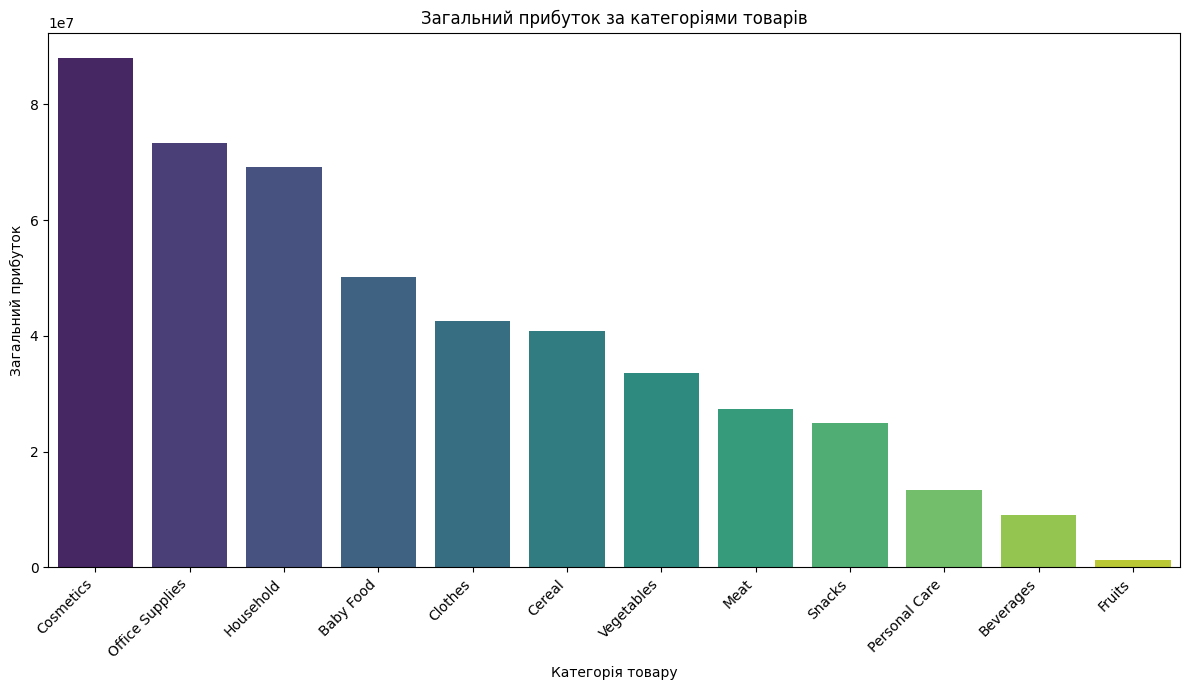

/tmp/ipykernel_1888/4135916163.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_category.index, y=sales_by_category['Total_Units_Sold'], palette='magma')


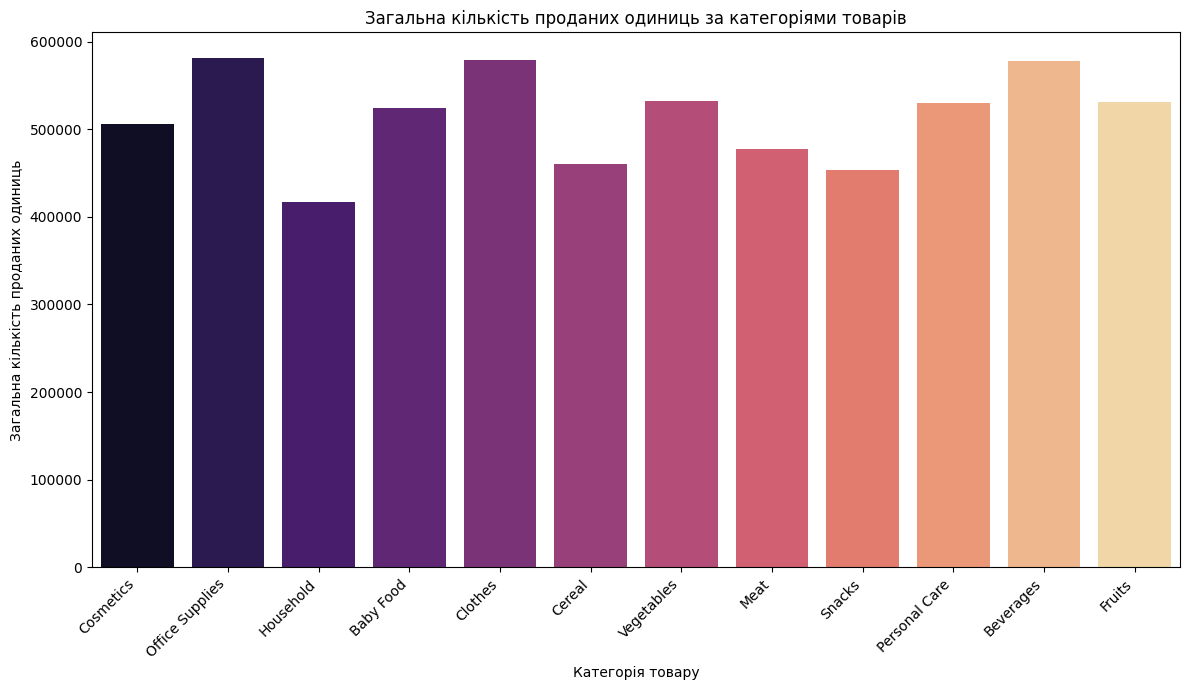

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Групування за категоріями товарів
sales_by_category = merged_df.groupby('Product Category').agg(
    Total_Units_Sold=('Units Sold', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Cost=('Cost', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values(by='Total_Profit', ascending=False)

print("\n--- Продажі за категоріями товарів ---")
display(sales_by_category)

# Візуалізація прибутку за категоріями товарів
plt.figure(figsize=(12, 7))
sns.barplot(x=sales_by_category.index, y=sales_by_category['Total_Profit'], palette='viridis')
plt.title('Загальний прибуток за категоріями товарів')
plt.xlabel('Категорія товару')
plt.ylabel('Загальний прибуток')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Візуалізація кількості проданих одиниць за категоріями товарів
plt.figure(figsize=(12, 7))
sns.barplot(x=sales_by_category.index, y=sales_by_category['Total_Units_Sold'], palette='magma')
plt.title('Загальна кількість проданих одиниць за категоріями товарів')
plt.xlabel('Категорія товару')
plt.ylabel('Загальна кількість проданих одиниць')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Аналіз продажів за географією (країни та регіони)

Проаналізуємо загальні показники продажів (одиниці, дохід, витрати, прибуток) у розрізі країн та регіонів, щоб зрозуміти географічний розподіл успіху компанії.


--- Продажі за країнами (топ-10 за прибутком) ---


,Total_Units_Sold,Total_Revenue,Total_Cost,Total_Profit
Country Name,,,,
Andorra,185686.0,47756693.17,32346656.54,15410036.63
Ukraine,164577.0,53252317.54,38447391.80,14804925.74
Malta,173641.0,47145320.81,32535192.93,14610127.88
San Marino,192228.0,47883708.48,34090715.67,13792992.81
Hungary,152242.0,42408249.12,28622018.09,13786231.03
Macedonia,203078.0,49222085.25,35537985.30,13684099.95
Czech Republic,142446.0,53543932.14,39908338.36,13635593.78
Russia,165954.0,46051659.81,32783977.17,13267682.64
Bosnia and Herzegovina,153545.0,50117508.49,36859905.72,13257602.77


/tmp/ipykernel_1888/2303081690.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_country.head(10).index, y=sales_by_country.head(10)['Total_Profit'], palette='cubehelix')


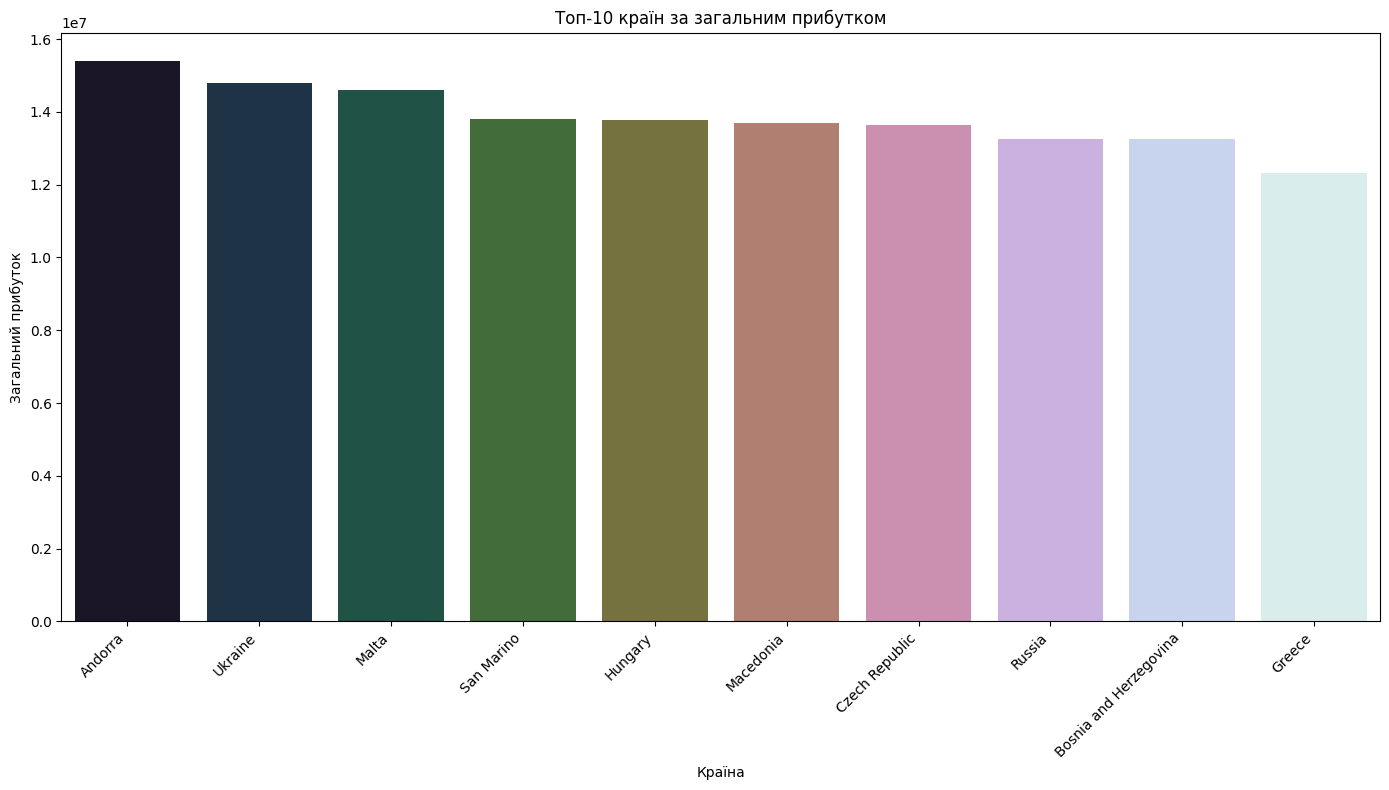


--- Продажі за регіонами ---


,Total_Units_Sold,Total_Revenue,Total_Cost,Total_Profit
region,,,,
Europe,5761244.0,1.505653e+09,1.057096e+09,4.485568e+08
Asia,410427.0,9.333089e+07,6.817863e+07,2.515225e+07


/tmp/ipykernel_1888/2303081690.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_region.index, y=sales_by_region['Total_Profit'], palette='mako')


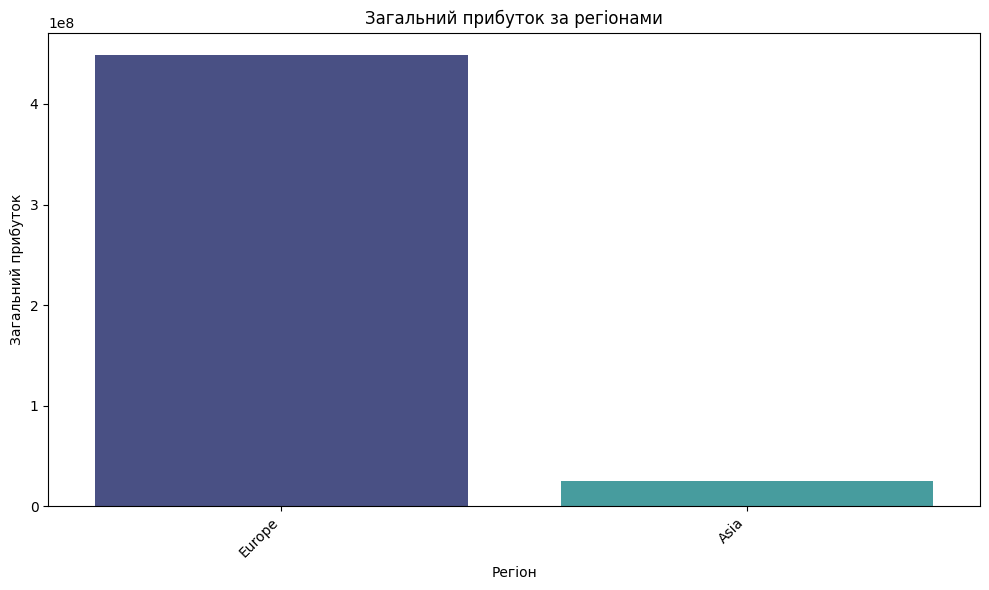

In [ ]:
# Групування за країнами
sales_by_country = merged_df.groupby('Country Name').agg(
    Total_Units_Sold=('Units Sold', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Cost=('Cost', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values(by='Total_Profit', ascending=False)

print("\n--- Продажі за країнами (топ-10 за прибутком) ---")
display(sales_by_country.head(10))

# Візуалізація прибутку за країнами (топ-10)
plt.figure(figsize=(14, 8))
sns.barplot(x=sales_by_country.head(10).index, y=sales_by_country.head(10)['Total_Profit'], palette='cubehelix')
plt.title('Топ-10 країн за загальним прибутком')
plt.xlabel('Країна')
plt.ylabel('Загальний прибуток')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Групування за регіонами
sales_by_region = merged_df.groupby('region').agg(
    Total_Units_Sold=('Units Sold', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Cost=('Cost', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values(by='Total_Profit', ascending=False)

print("\n--- Продажі за регіонами ---")
display(sales_by_region)

# Візуалізація прибутку за регіонами
plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_region.index, y=sales_by_region['Total_Profit'], palette='mako')
plt.title('Загальний прибуток за регіонами')
plt.xlabel('Регіон')
plt.ylabel('Загальний прибуток')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Аналіз продажів за каналами продажу (онлайн або офлайн)

Проаналізуємо загальні показники продажів (одиниці, дохід, витрати, прибуток) у розрізі каналів продажу, щоб визначити ефективність кожного каналу.


--- Продажі за каналами продажу ---


,Total_Units_Sold,Total_Revenue,Total_Cost,Total_Profit
Sales Channel,,,,
Offline,3113412.0,8.100305e+08,5.715191e+08,2.385113e+08
Online,3058259.0,7.889533e+08,5.537556e+08,2.351977e+08


/tmp/ipykernel_1888/304514874.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_channel.index, y=sales_by_channel['Total_Profit'], palette='rocket')


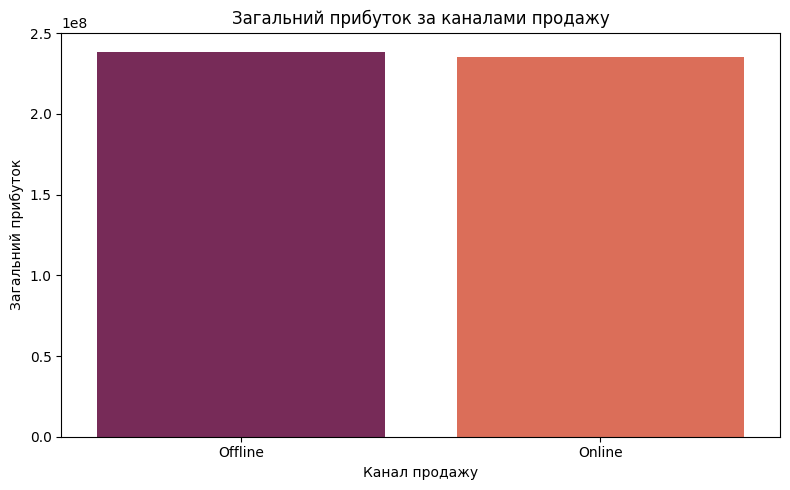

/tmp/ipykernel_1888/304514874.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_channel.index, y=sales_by_channel['Total_Units_Sold'], palette='crest')


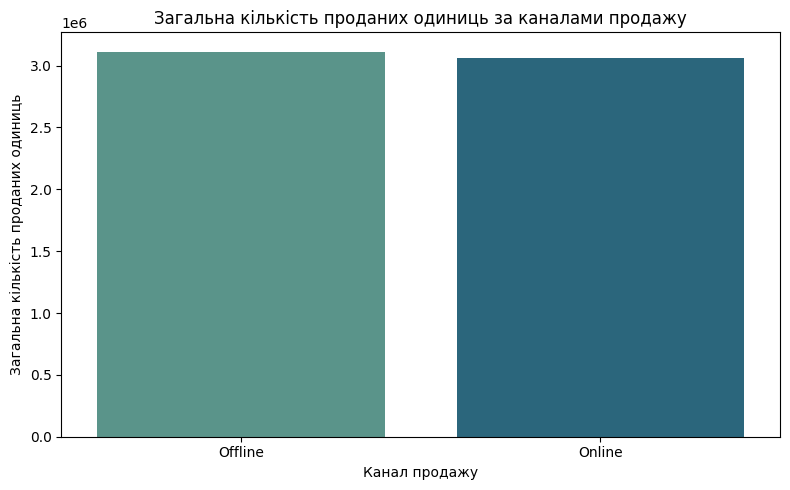

Variable                   Type         Data/Info
-------------------------------------------------
average_profit_per_order   float64      380183.8162600321
average_units_sold         float64      4953.186998394864
base_dir                   str          /content/unzipped_data/13. Final project/
check_missing_values       function     <function check_missing_values at 0x7bdfdea214e0>
countries_df               DataFrame                      name al<...>n\n[247 rows x 5 columns]
countries_path             str          /content/unzipped_data/13<...>nal project/countries.csv
dirs                       list         n=0
events_df                  DataFrame           Order ID Order Dat<...>n[1246 rows x 10 columns]
events_path                str          /content/unzipped_data/13<...> Final project/events.csv
extract_dir                str          /content/unzipped_data
files                      list         n=0
initial_rows_countries     int          249
initial_rows_events        int   

In [ ]:
# Групування за каналами продажу
sales_by_channel = merged_df.groupby('Sales Channel').agg(
    Total_Units_Sold=('Units Sold', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Cost=('Cost', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values(by='Total_Profit', ascending=False)

print("\n--- Продажі за каналами продажу ---")
display(sales_by_channel)

# Візуалізація прибутку за каналами продажу
plt.figure(figsize=(8, 5))
sns.barplot(x=sales_by_channel.index, y=sales_by_channel['Total_Profit'], palette='rocket')
plt.title('Загальний прибуток за каналами продажу')
plt.xlabel('Канал продажу')
plt.ylabel('Загальний прибуток')
plt.tight_layout()
plt.show()

# Візуалізація кількості проданих одиниць за каналами продажу
plt.figure(figsize=(8, 5))
sns.barplot(x=sales_by_channel.index, y=sales_by_channel['Total_Units_Sold'], palette='crest')
plt.title('Загальна кількість проданих одиниць за каналами продажу')
plt.xlabel('Канал продажу')
plt.ylabel('Загальна кількість проданих одиниць')
plt.tight_layout()
plt.show()
%whos


### Detaillierterer Vergleich der Kanäle


--- Zusätzliche Metriken nach Vertriebskanal ---


,Sales Channel,Average_Units_Sold,Average_Profit_Per_Order
0,Offline,5013.545894,384076.21161
1,Online,4893.214400,376316.33224



--- Top-Produktkategorien nach Vertriebskanal (nach Gewinn) ---


/tmp/ipykernel_1888/165576017.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Profit', data=top_categories_channel, palette='viridis', ax=axes[i])
/tmp/ipykernel_1888/165576017.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Profit', data=top_categories_channel, palette='viridis', ax=axes[i])


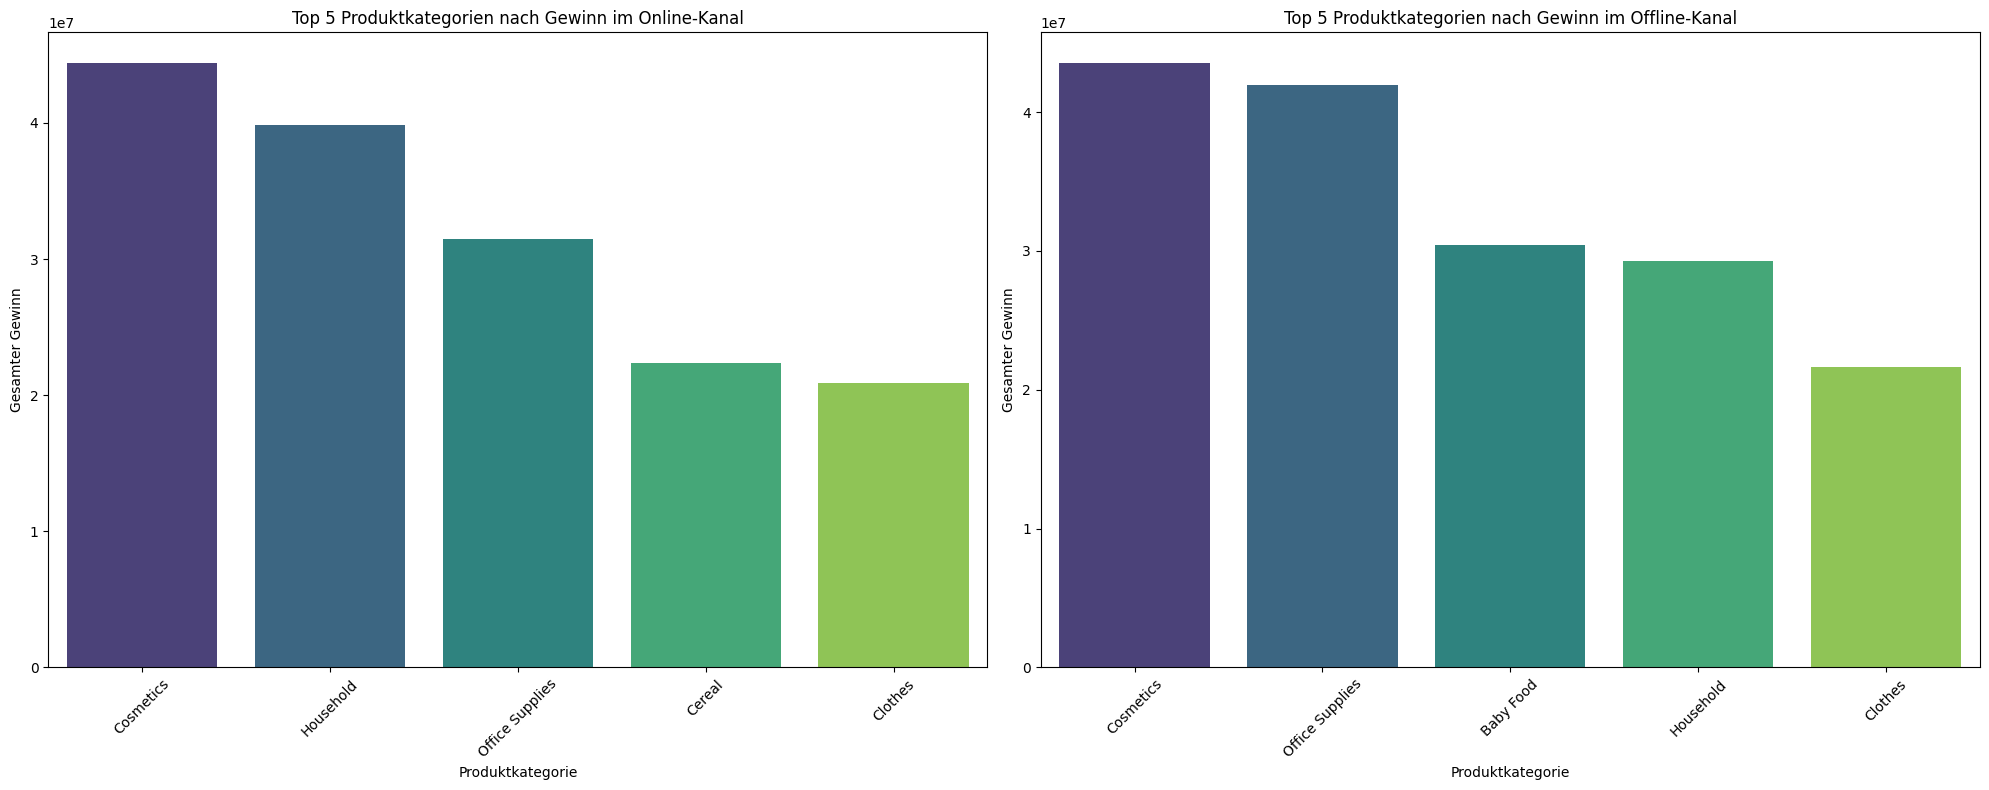

In [ ]:
print("\n--- Zusätzliche Metriken nach Vertriebskanal ---")

channel_metrics = merged_df.groupby('Sales Channel').agg(
    Average_Units_Sold=('Units Sold', 'mean'),
    Average_Profit_Per_Order=('Profit', lambda x: x.sum() / merged_df.loc[x.index, 'Order ID'].nunique())
).reset_index()

display(channel_metrics)

# Top-Produktkategorien nach Kanal
print("\n--- Top-Produktkategorien nach Vertriebskanal (nach Gewinn) ---")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for i, channel in enumerate(merged_df['Sales Channel'].unique()):
    channel_df = merged_df[merged_df['Sales Channel'] == channel]
    top_categories_channel = channel_df.groupby('Product Category')['Profit'].sum().nlargest(5).reset_index()

    sns.barplot(x='Product Category', y='Profit', data=top_categories_channel, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Top 5 Produktkategorien nach Gewinn im {channel}-Kanal')
    axes[i].set_xlabel('Produktkategorie')
    axes[i].set_ylabel('Gesamter Gewinn')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Аналіз часового інтервалу між замовленням та відвантаженням

Проаналізуємо час, що проходить між датою замовлення та датою відвантаження (`Shipment_Duration`), щоб виявити можливі затримки та оптимізувати логістику. Розглянемо цей показник у розрізі категорій товарів, країн та регіонів.

Додано колонку 'Shipment_Duration'.

--- Середня тривалість відвантаження за категоріями товарів ---


,Shipment_Duration
Product Category,
Office Supplies,27.283186
Cereal,27.198020
Baby Food,26.647619
Cosmetics,25.879630
Meat,25.735294
Snacks,25.263158
Fruits,24.475728
Vegetables,24.438095
Beverages,23.946903


/tmp/ipykernel_1888/2142434846.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shipment_duration_by_category.index, y=shipment_duration_by_category.values, palette='viridis')


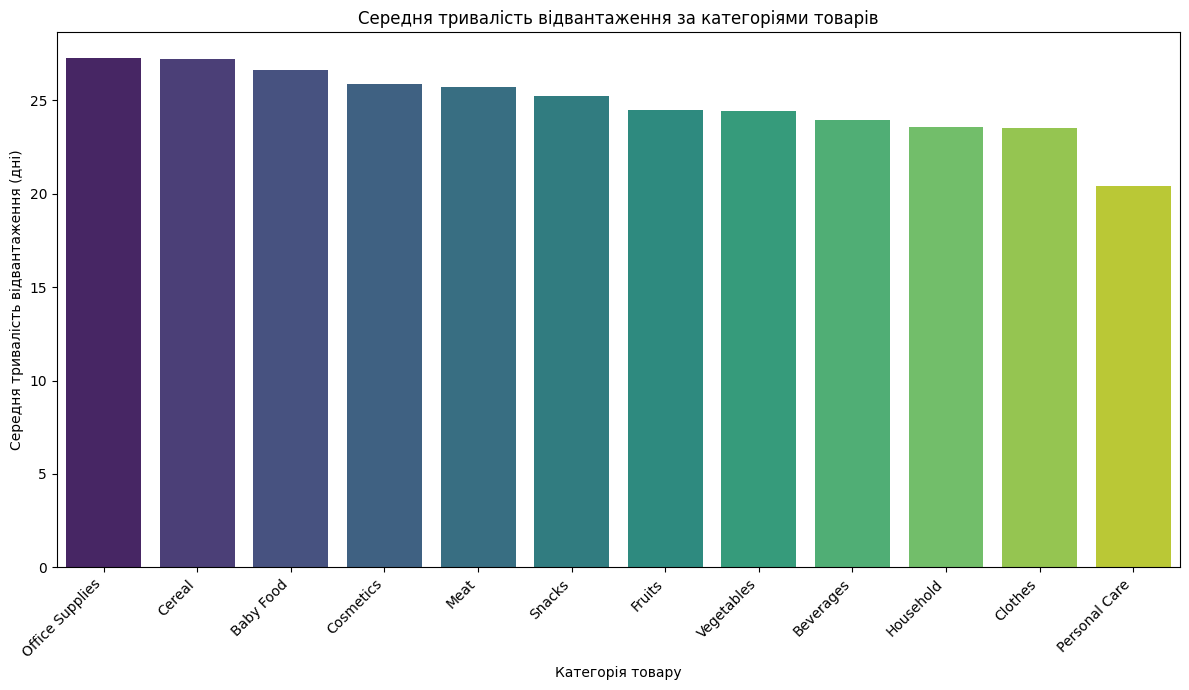


--- Середня тривалість відвантаження за країнами (топ-10) ---


,Shipment_Duration
Country Name,
Hungary,32.640000
Georgia,29.695652
Austria,28.500000
Slovakia,28.466667
Luxembourg,27.750000
Lithuania,27.560000
Poland,27.464286
Russia,27.375000
Monaco,26.846154


/tmp/ipykernel_1888/2142434846.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shipment_duration_by_country.head(10).index, y=shipment_duration_by_country.head(10).values, palette='cubehelix')


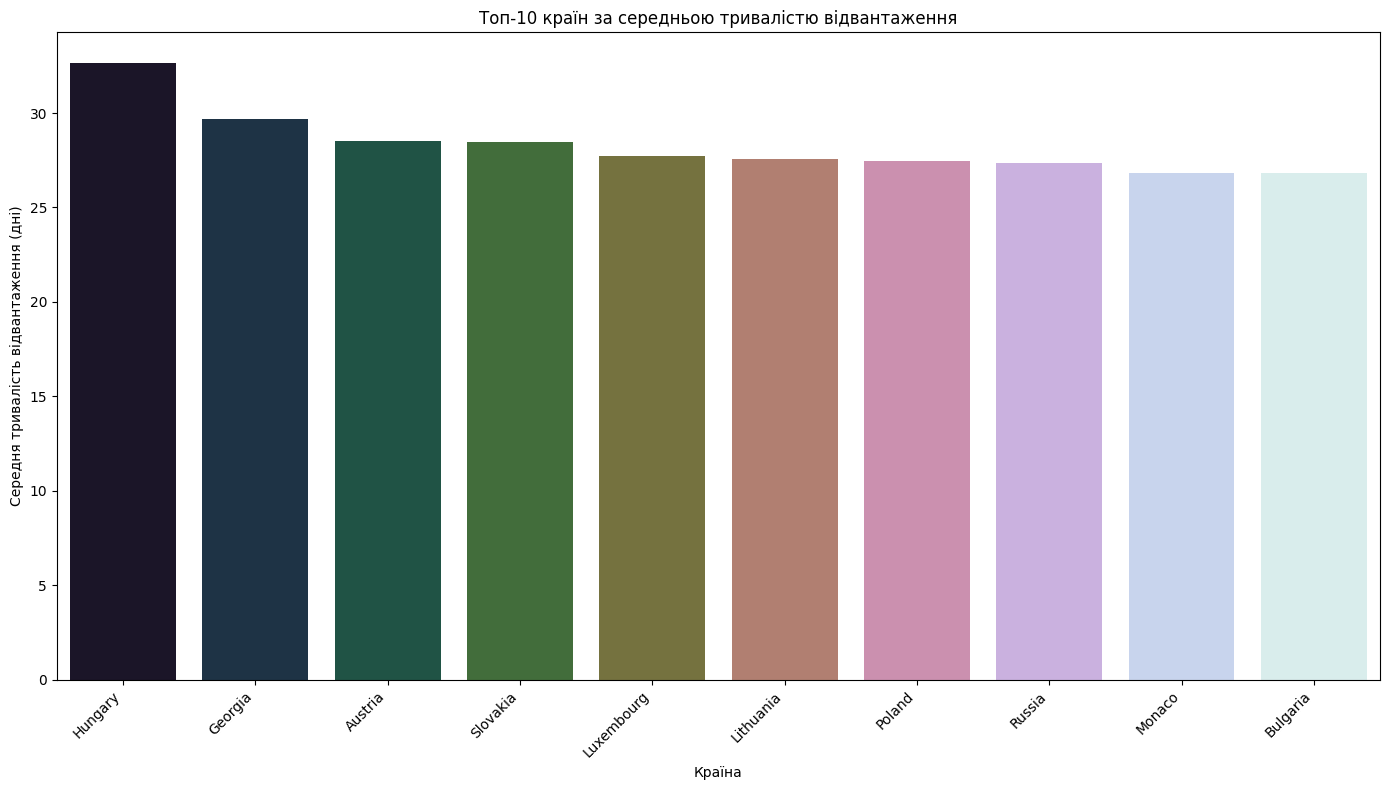


--- Середня тривалість відвантаження за регіонами ---


,Shipment_Duration
region,
Asia,26.085366
Europe,24.790378


/tmp/ipykernel_1888/2142434846.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shipment_duration_by_region.index, y=shipment_duration_by_region.values, palette='mako')


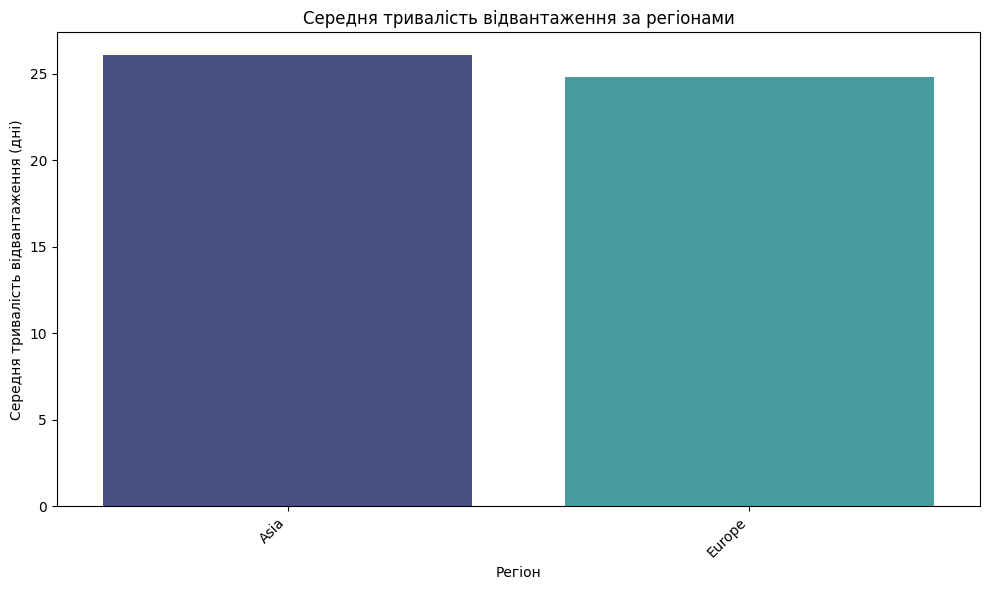

In [ ]:
# Розрахунок тривалості відвантаження (у днях)
merged_df['Shipment_Duration'] = (merged_df['Ship Date'] - merged_df['Order Date']).dt.days

print("Додано колонку 'Shipment_Duration'.")

# Аналіз тривалості відвантаження за категоріями товарів
shipment_duration_by_category = merged_df.groupby('Product Category')['Shipment_Duration'].mean().sort_values(ascending=False)

print("\n--- Середня тривалість відвантаження за категоріями товарів ---")
display(shipment_duration_by_category)

plt.figure(figsize=(12, 7))
sns.barplot(x=shipment_duration_by_category.index, y=shipment_duration_by_category.values, palette='viridis')
plt.title('Середня тривалість відвантаження за категоріями товарів')
plt.xlabel('Категорія товару')
plt.ylabel('Середня тривалість відвантаження (дні)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Аналіз тривалості відвантаження за країнами
shipment_duration_by_country = merged_df.groupby('Country Name')['Shipment_Duration'].mean().sort_values(ascending=False)

print("\n--- Середня тривалість відвантаження за країнами (топ-10) ---")
display(shipment_duration_by_country.head(10))

plt.figure(figsize=(14, 8))
sns.barplot(x=shipment_duration_by_country.head(10).index, y=shipment_duration_by_country.head(10).values, palette='cubehelix')
plt.title('Топ-10 країн за середньою тривалістю відвантаження')
plt.xlabel('Країна')
plt.ylabel('Середня тривалість відвантаження (дні)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Аналіз тривалості відвантаження за регіонами
shipment_duration_by_region = merged_df.groupby('region')['Shipment_Duration'].mean().sort_values(ascending=False)

print("\n--- Середня тривалість відвантаження за регіонами ---")
display(shipment_duration_by_region)

plt.figure(figsize=(10, 6))
sns.barplot(x=shipment_duration_by_region.index, y=shipment_duration_by_region.values, palette='mako')
plt.title('Середня тривалість відвантаження за регіонами')
plt.xlabel('Регіон')
plt.ylabel('Середня тривалість відвантаження (дні)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Аналіз кореляції між прибутком та часом відвантаження

Проаналізуємо, чи залежить прибуток від часу, необхідного для відвантаження, агрегуючи дані за тривалістю відвантаження та візуалізуючи цей зв'язок.


--- Середній прибуток за тривалістю відвантаження ---


,Shipment_Duration,Profit
0,0,337888.328421
1,1,338390.965263
2,2,346590.220400
3,3,285391.693226
4,4,278809.762593


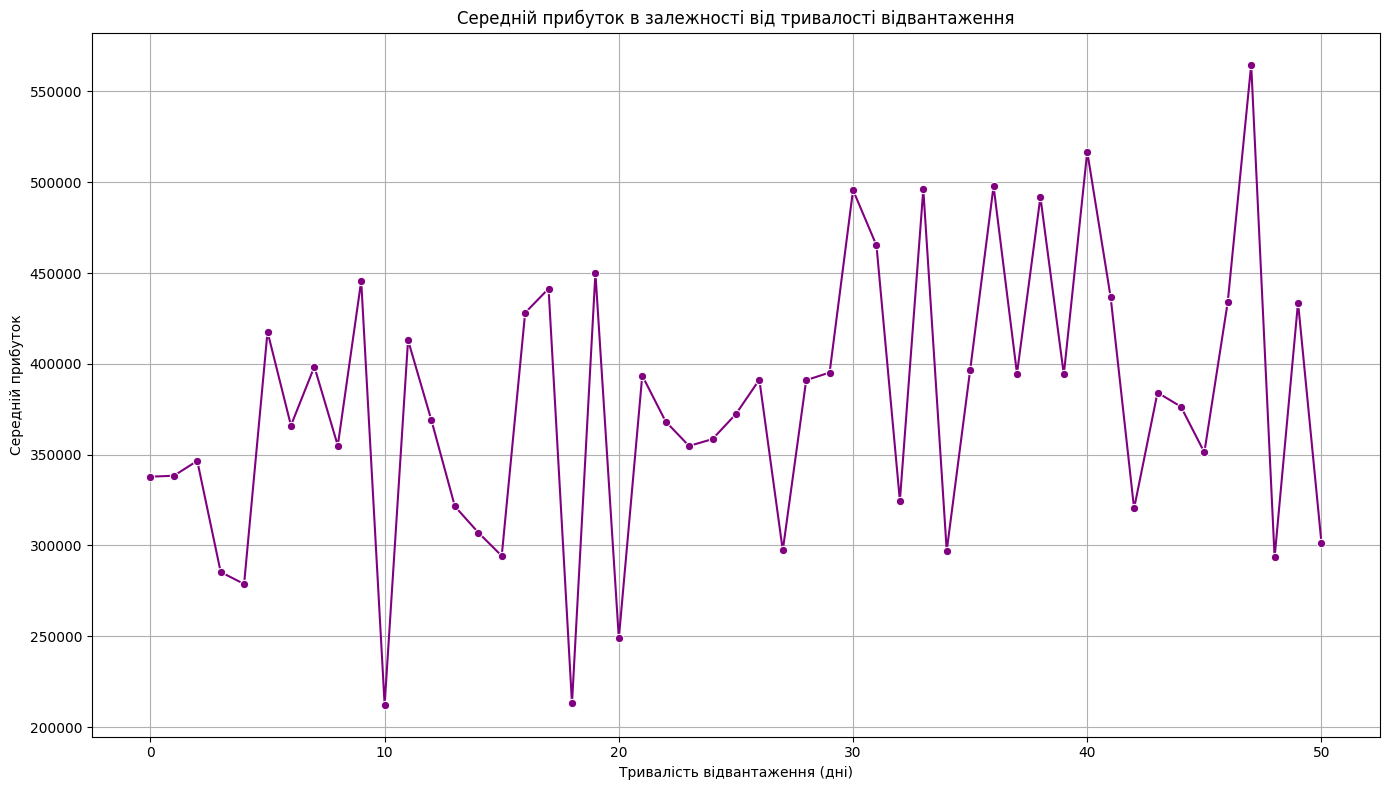

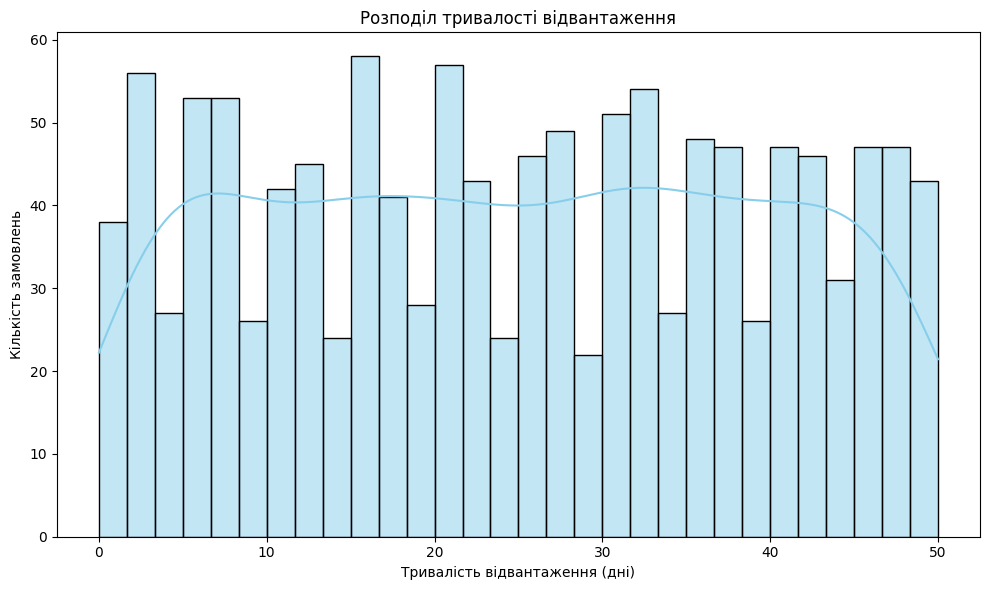

In [ ]:
# Агрегування даних за тривалістю відвантаження та розрахунок середнього прибутку
profit_by_shipment_duration = merged_df.groupby('Shipment_Duration')['Profit'].mean().reset_index()

print("\n--- Середній прибуток за тривалістю відвантаження ---")
display(profit_by_shipment_duration.sort_values(by='Shipment_Duration').head())

# Візуалізація залежності прибутку від тривалості відвантаження
plt.figure(figsize=(14, 8))
sns.lineplot(x='Shipment_Duration', y='Profit', data=profit_by_shipment_duration, marker='o', color='purple')
plt.title('Середній прибуток в залежності від тривалості відвантаження')
plt.xlabel('Тривалість відвантаження (дні)')
plt.ylabel('Середній прибуток')
plt.grid(True)
plt.tight_layout()
plt.show()

# Додаткова візуалізація: розподіл тривалості відвантаження
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['Shipment_Duration'], bins=30, kde=True, color='skyblue')
plt.title('Розподіл тривалості відвантаження')
plt.xlabel('Тривалість відвантаження (дні)')
plt.ylabel('Кількість замовлень')
plt.tight_layout()
plt.show()

## Аналіз динаміки продажів у часі

Проаналізуємо та візуалізуємо тенденції продажів у часі (місячно, квартально, щорічно) за категоріями товарів, країнами та регіонами, щоб виявити закономірності та сезонність.


--- Місячні продажі --- 


,Total_Profit,Total_Units_Sold
Order Date,,
2010-01-31,8290169.53,105713.0
2010-02-28,4306485.07,68209.0
2010-03-31,3093055.70,49618.0
2010-04-30,2320389.85,34618.0
2010-05-31,6321046.70,83044.0


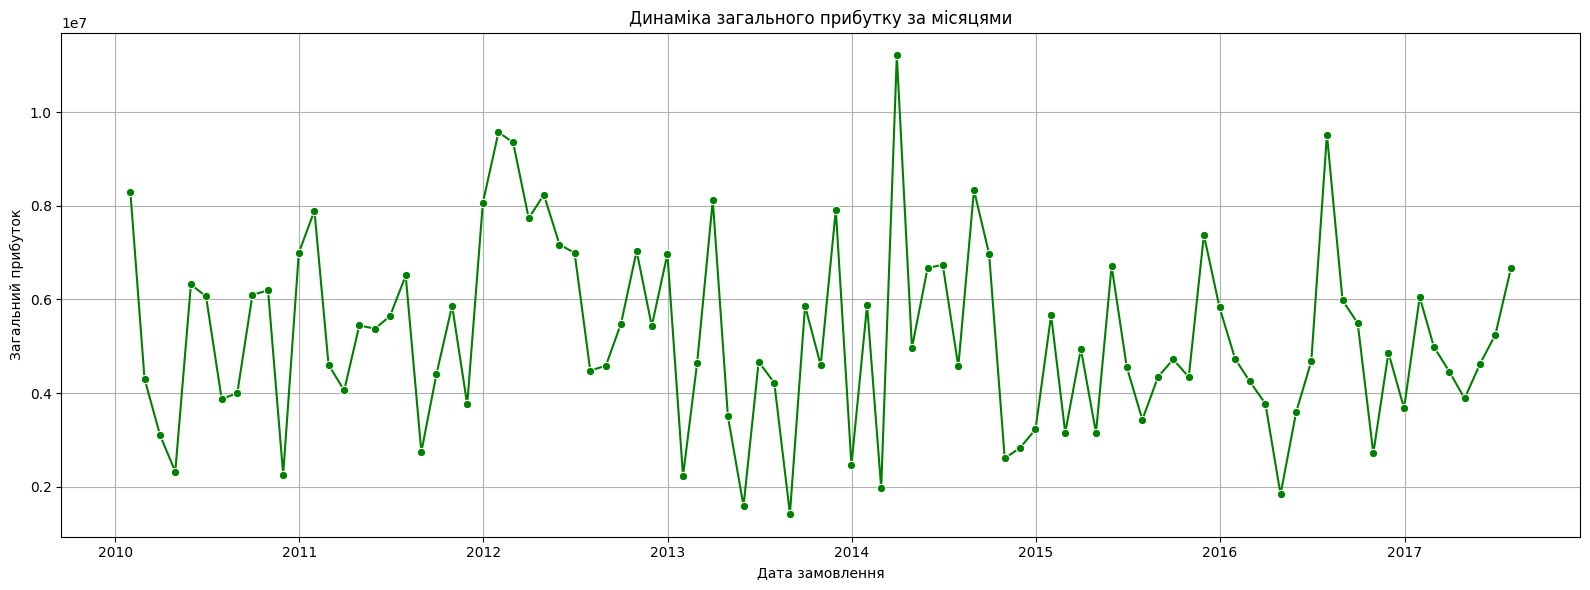

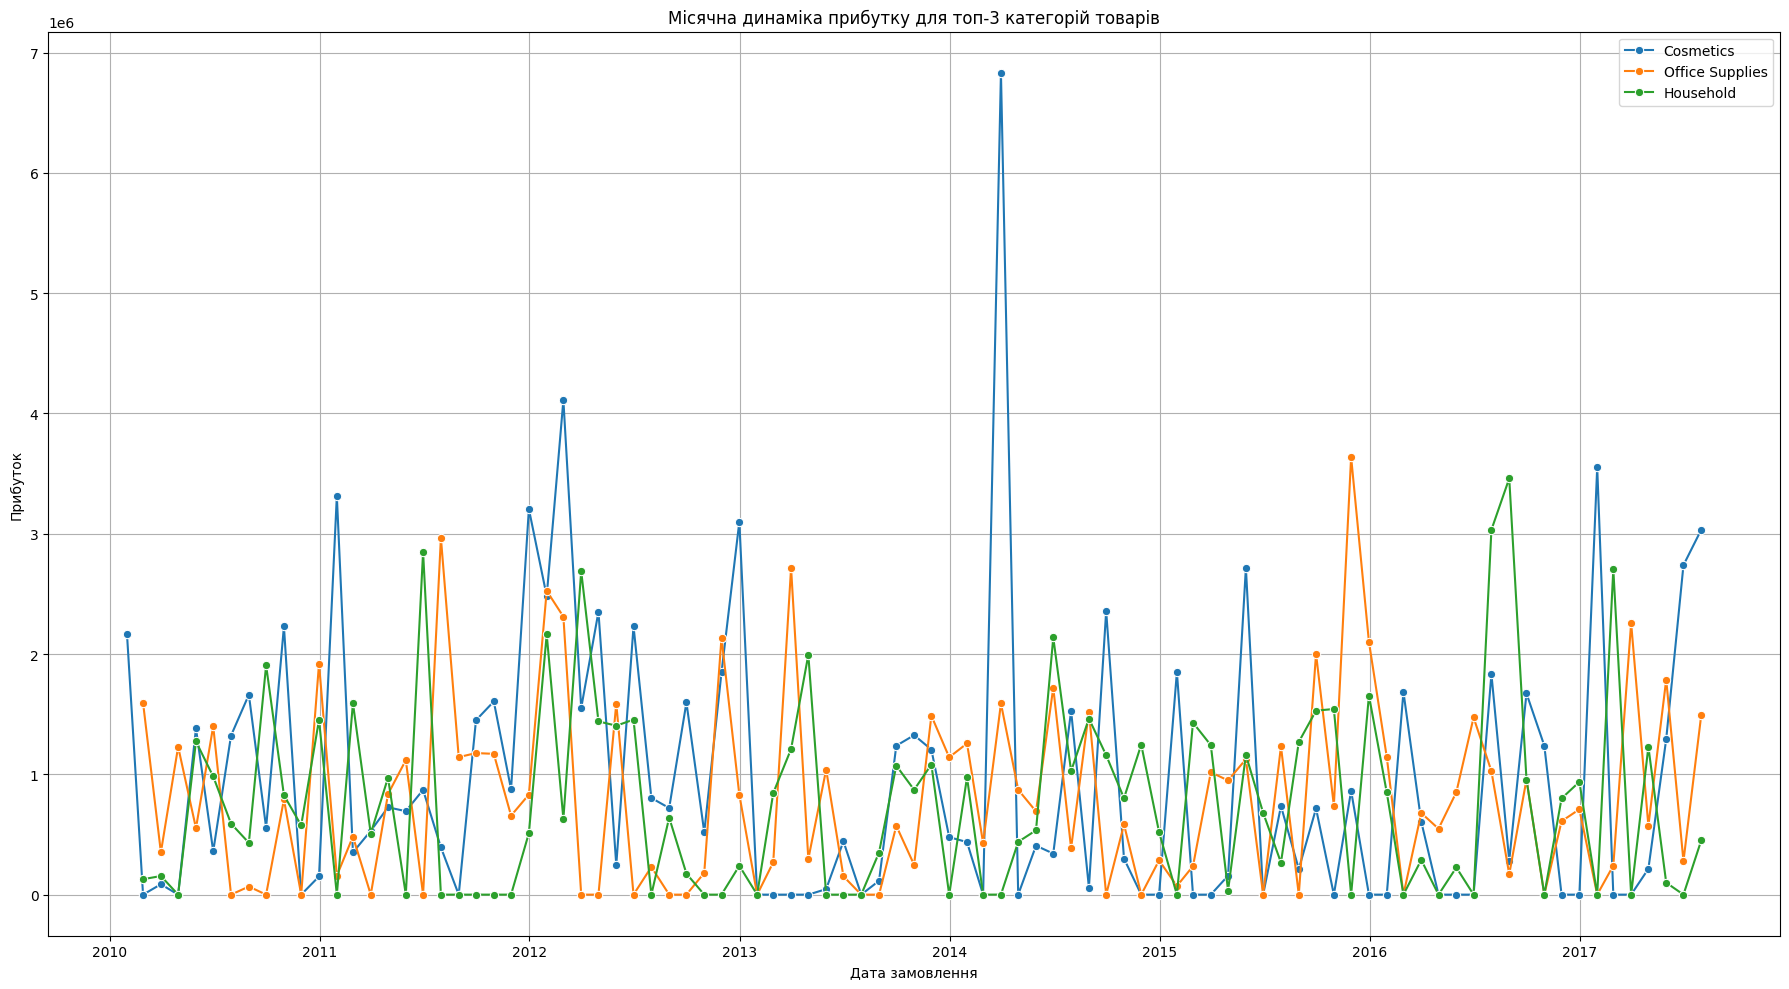

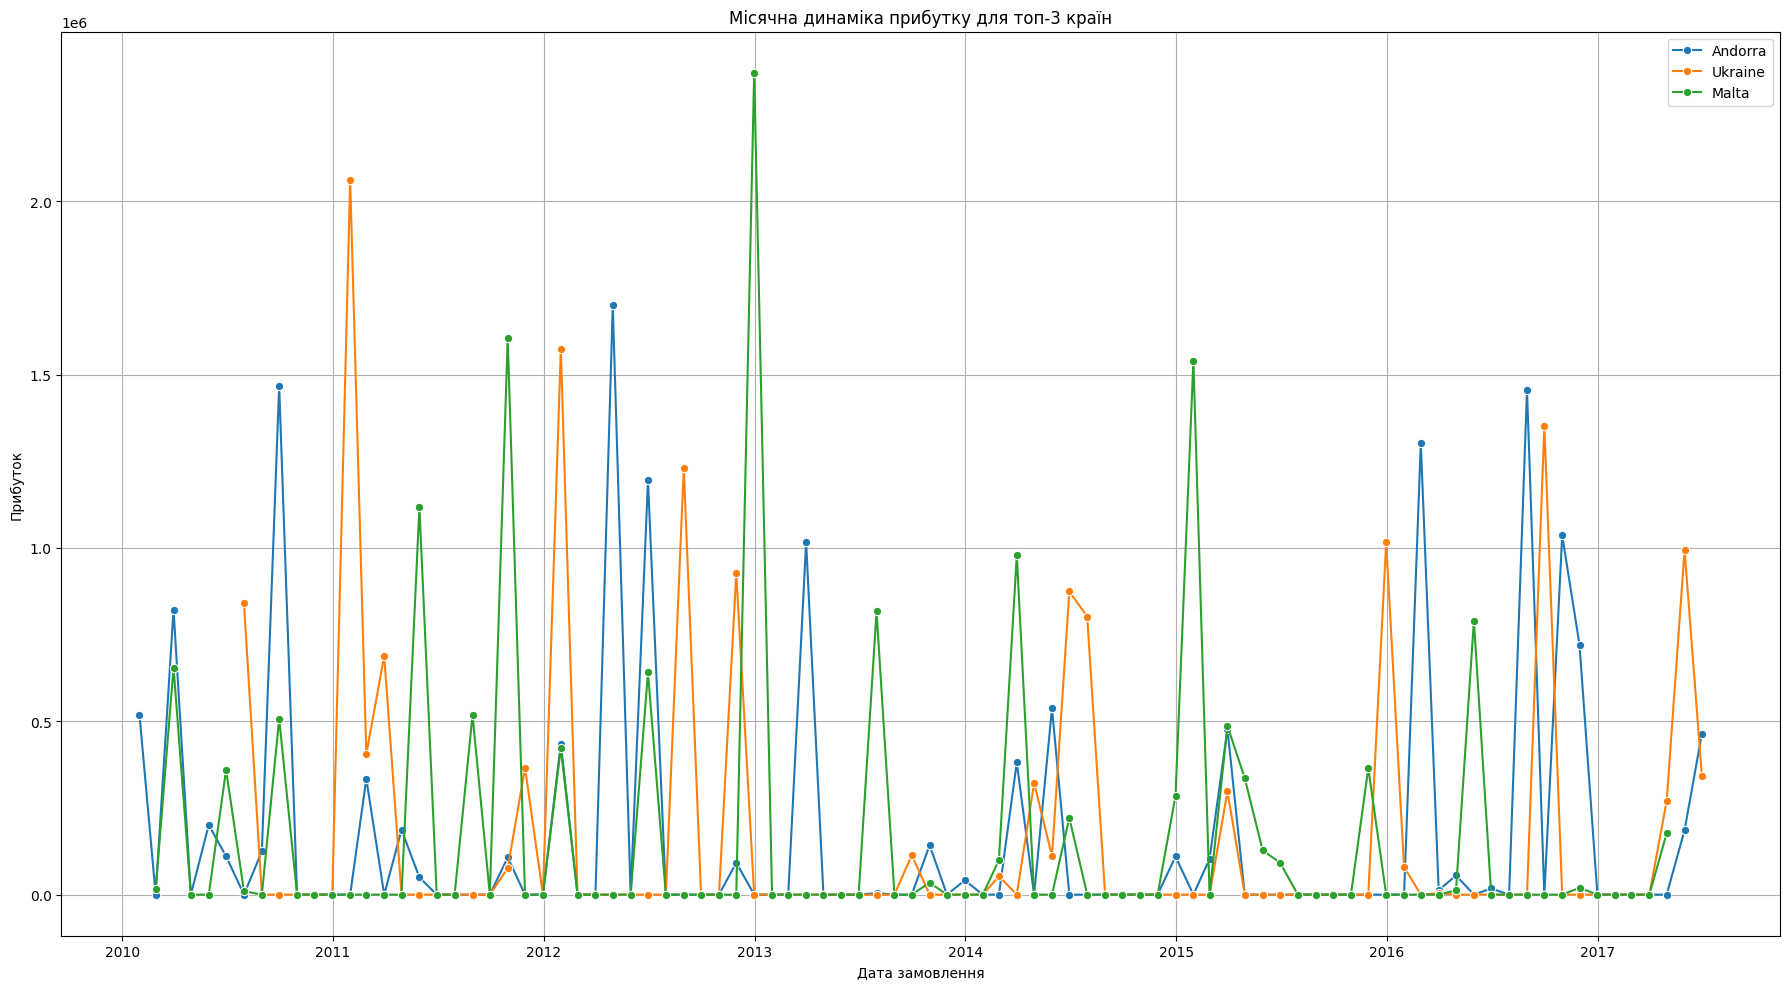

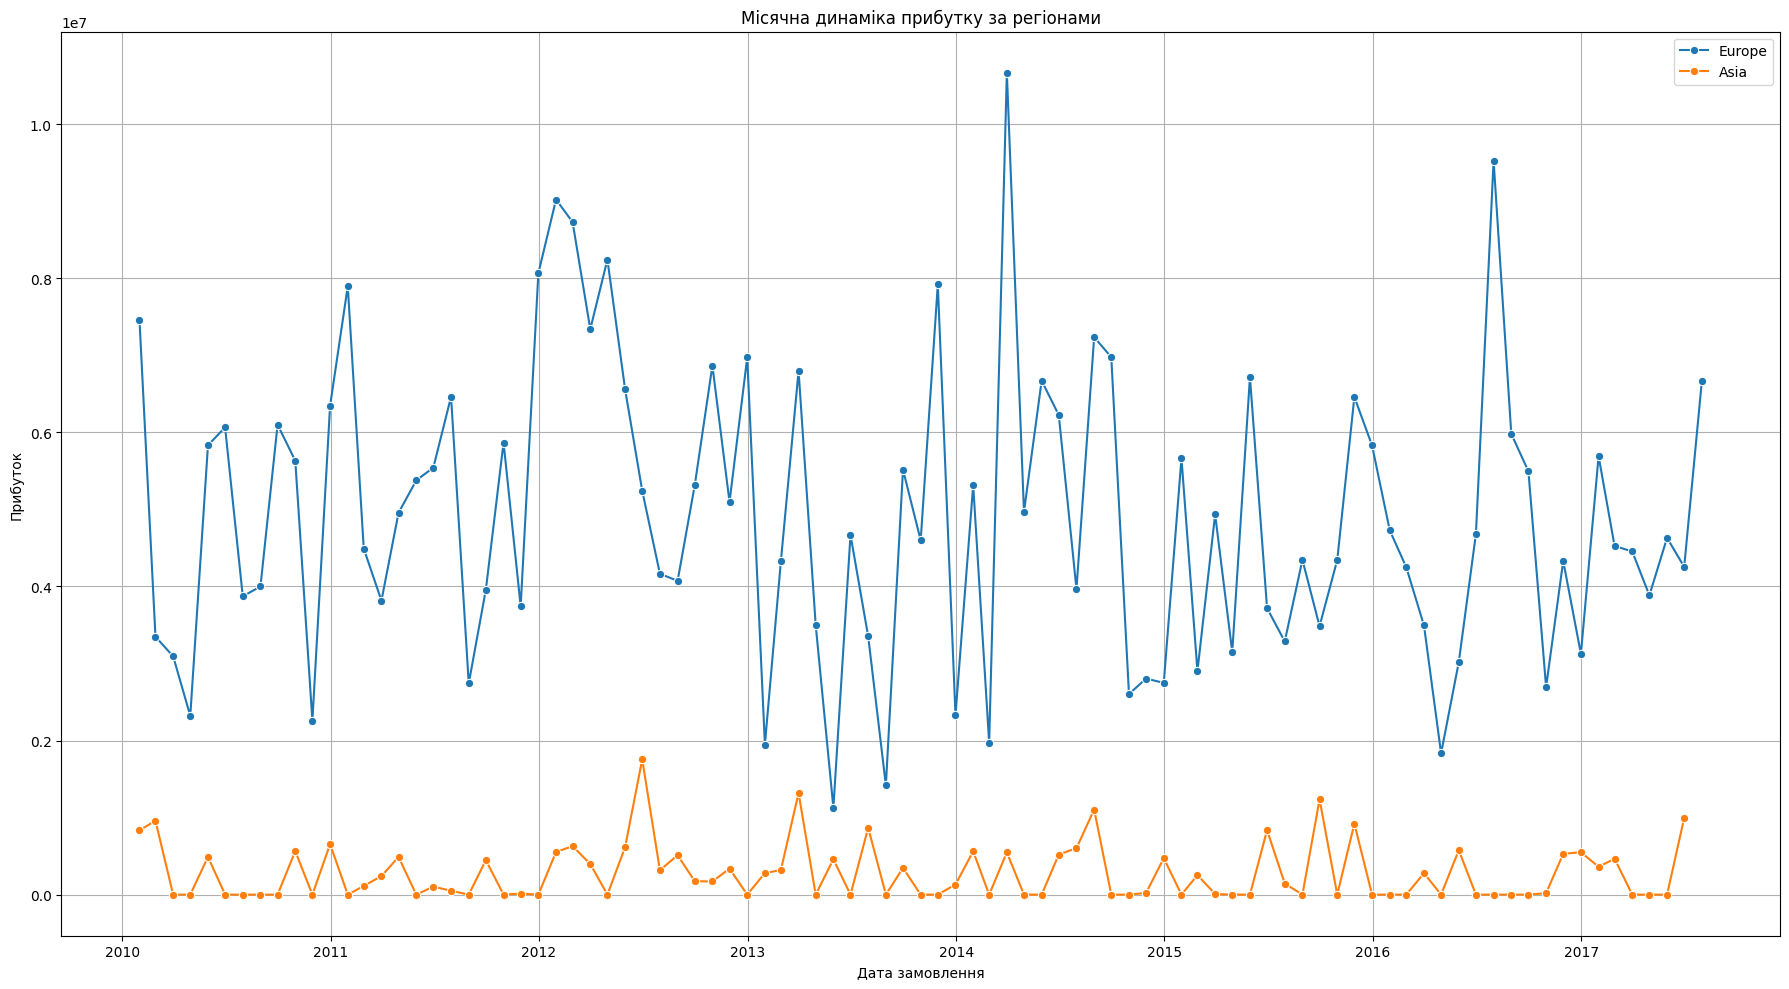

In [ ]:
# Встановлення 'Order Date' як індексу для часових рядів
time_series_df = merged_df.set_index('Order Date').sort_index()

# Агрегування продажів за місяцями та подальше перейменування колонок
sales_monthly = time_series_df.resample('ME').agg({
    'Profit': 'sum',
    'Units Sold': 'sum'
})
sales_monthly.rename(columns={'Profit': 'Total_Profit', 'Units Sold': 'Total_Units_Sold'}, inplace=True)

print("\n--- Місячні продажі --- ")
display(sales_monthly.head())

plt.figure(figsize=(16, 6))
sns.lineplot(x=sales_monthly.index, y=sales_monthly['Total_Profit'], marker='o', color='green')
plt.title('Динаміка загального прибутку за місяцями')
plt.xlabel('Дата замовлення')
plt.ylabel('Загальний прибуток')
plt.grid(True)
plt.tight_layout()
plt.show()

# Аналіз продажів за місяцями за категоріями товарів (топ-3 категорії)
# Спочатку знайдемо топ-3 категорії за загальним прибутком
top_3_categories = merged_df.groupby('Product Category')['Profit'].sum().nlargest(3).index

plt.figure(figsize=(18, 10))
for category in top_3_categories:
    category_sales_monthly = time_series_df[time_series_df['Product Category'] == category].resample('ME').agg({
        'Profit': 'sum'
    })
    sns.lineplot(x=category_sales_monthly.index, y=category_sales_monthly['Profit'], label=category, marker='o')

plt.title('Місячна динаміка прибутку для топ-3 категорій товарів')
plt.xlabel('Дата замовлення')
plt.ylabel('Прибуток')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Аналіз продажів за місяцями за країнами (топ-3 країни)
# Спочатку знайдемо топ-3 країни за загальним прибутком
top_3_countries = merged_df.groupby('Country Name')['Profit'].sum().nlargest(3).index

plt.figure(figsize=(18, 10))
for country in top_3_countries:
    country_sales_monthly = time_series_df[time_series_df['Country Name'] == country].resample('ME').agg({
        'Profit': 'sum'
    })
    sns.lineplot(x=country_sales_monthly.index, y=country_sales_monthly['Profit'], label=country, marker='o')

plt.title('Місячна динаміка прибутку для топ-3 країн')
plt.xlabel('Дата замовлення')
plt.ylabel('Прибуток')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Аналіз продажів за місяцями за регіонами
plt.figure(figsize=(18, 10))
for region in merged_df['region'].unique():
    region_sales_monthly = time_series_df[time_series_df['region'] == region].resample('ME').agg({
        'Profit': 'sum'
    })
    sns.lineplot(x=region_sales_monthly.index, y=region_sales_monthly['Profit'], label=region, marker='o')

plt.title('Місячна динаміка прибутку за регіонами')
plt.xlabel('Дата замовлення')
plt.ylabel('Прибуток')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Аналіз продажів за днями тижня та сезонність

Визначимо, як розподіляються продажі за днями тижня та чи є сезонність для окремих товарів.


--- Продажі за днями тижня ---


/tmp/ipykernel_1888/1008016478.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_day_of_week = merged_df.groupby('Day_of_Week').agg(


,Total_Units_Sold,Total_Profit
Day_of_Week,,
Monday,933677.0,72156995.30
Tuesday,833975.0,63512866.99
Wednesday,839870.0,67768122.43
Thursday,818022.0,60108355.32
Friday,787802.0,73323427.18
Saturday,970549.0,68743185.28
Sunday,987776.0,68096082.56


/tmp/ipykernel_1888/1008016478.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_day_of_week.index, y=sales_by_day_of_week['Total_Profit'], palette='plasma')


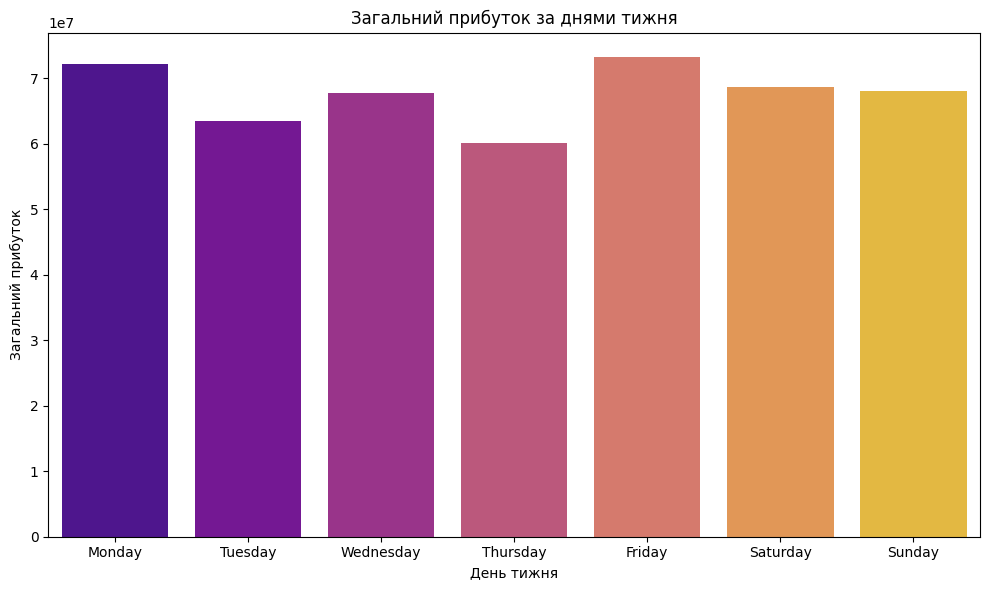

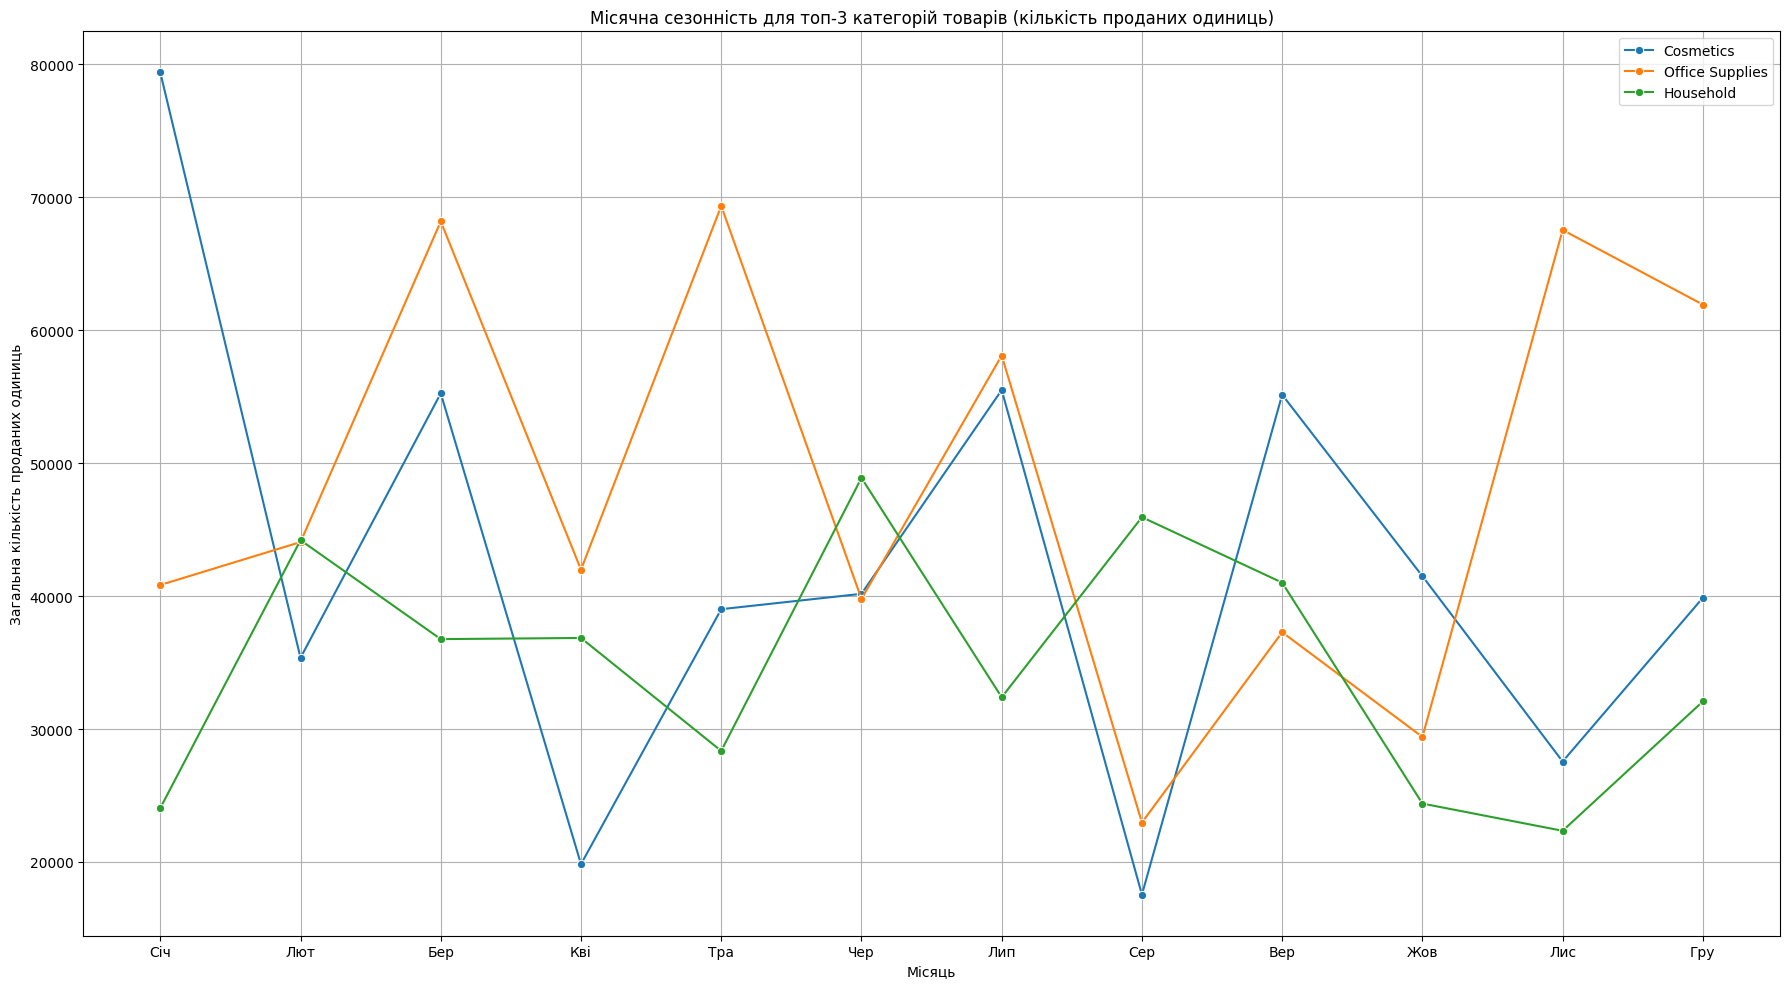

In [ ]:
# Додаємо колонку з днем тижня
merged_df['Day_of_Week'] = merged_df['Order Date'].dt.day_name()

# Порядок днів тижня для коректної візуалізації
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
merged_df['Day_of_Week'] = pd.Categorical(merged_df['Day_of_Week'], categories=day_order, ordered=True)

# Продажі за днями тижня
sales_by_day_of_week = merged_df.groupby('Day_of_Week').agg(
    Total_Units_Sold=('Units Sold', 'sum'),
    Total_Profit=('Profit', 'sum')
).reindex(day_order)

print("\n--- Продажі за днями тижня ---")
display(sales_by_day_of_week)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_day_of_week.index, y=sales_by_day_of_week['Total_Profit'], palette='plasma')
plt.title('Загальний прибуток за днями тижня')
plt.xlabel('День тижня')
plt.ylabel('Загальний прибуток')
plt.tight_layout()
plt.show()

# Сезонність товарів: місячні продажі для окремих категорій
# Використаємо топ-3 категорії, визначені раніше

merged_df['Month'] = merged_df['Order Date'].dt.month

plt.figure(figsize=(18, 10))
for category in top_3_categories:
    # Групуємо за місяцями для кожної категорії
    seasonal_sales = merged_df[merged_df['Product Category'] == category].groupby('Month')['Units Sold'].sum()
    sns.lineplot(x=seasonal_sales.index, y=seasonal_sales.values, label=category, marker='o')

plt.title('Місячна сезонність для топ-3 категорій товарів (кількість проданих одиниць)')
plt.xlabel('Місяць')
plt.ylabel('Загальна кількість проданих одиниць')
plt.xticks(range(1, 13), ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Детальний аналітичний звіт та бізнес-висновки

Цей звіт містить комплексний аналіз даних про продажі, продукти, країни та події. Метою аналізу було виявлення ключових метрик, тенденцій, закономірностей та потенційних можливостей для оптимізації бізнес-процесів.

### 1. Огляд даних та ключові метрики компанії

**Дані були успішно завантажені, очищені від пропущених значень та аномалій.** Після об'єднання трьох таблиць (`events_df`, `products_df`, `countries_df`), було створено єдиний датафрейм `merged_df` з розширеною інформацією.

**Ключові метрики діяльності компанії:**
*   **Загальна кількість унікальних замовлень:** `1,246`
*   **Загальний дохід:** `1,598,983,761.26`
*   **Загальні витрати:** `1,125,274,726.20`
*   **Загальний прибуток:** `473,709,035.06`
*   **Загальна кількість охоплених країн:** `45`
*   **Загальна кількість охоплених регіонів:** `2` (Європа та Азія)
*   **Кількість унікальних категорій товарів:** `12`
*   **Середня кількість проданих одиниць за замовлення:** `4,953.19`
*   **Середній прибуток на замовлення:** `380,183.82`

**Бізнес-висновки:**
Компанія демонструє значні обсяги продажів та прибутку, оперуючи на 45 ринках у 2 регіонах. Високий середній прибуток на замовлення свідчить про ефективність ціноутворення та управління витратами.

### 2. Аналіз продажів за категоріями товарів

Аналіз показав суттєві відмінності у прибутковості та обсягах продажів між категоріями товарів.

**Топ-3 категорії за прибутком та кількістю проданих одиниць:**
*   **Косметика (Cosmetics):** Найбільш прибуткова категорія.
*   **Офісне приладдя (Office Supplies):** Друга за прибутковістю категорія.
*   **Одяг (Clothes):** Третя за прибутковістю категорія.

**Бізнес-висновки:**
Необхідно зосередити маркетингові зусилля та розвиток асортименту на високоприбуткових категоріях, таких як Косметика та Офісне приладдя. Можливо, варто переглянути цінову політику або оптимізувати витрати для менш прибуткових категорій (наприклад, Фрукти, Напої).

### 3. Аналіз продажів за географією (країни та регіони)

**Країни з найвищим прибутком (Топ-3):**
1.  Андорра
2.  Україна
3.  Мальта

**Регіональний розподіл прибутку:**
*   **Європа:** Переважна більшість прибутку та обсягів продажів зосереджена в Європі.
*   **Азія:** Значно менші показники в порівнянні з Європою.

**Бізнес-висновки:**
Європа є ключовим ринком для компанії, що вимагає подальшого розвитку та утримання позицій. Незважаючи на це, варто вивчити причини високої прибутковості в окремих країнах (Андорра, Україна, Мальта) для реплікації успішних стратегій на інших ринках. Також слід проаналізувати потенціал зростання на азіатських ринках та розробити стратегії для збільшення частки ринку в цьому регіоні.

### 4. Аналіз продажів за каналами продажу (онлайн або офлайн)

*   **Офлайн продажі:** Демонструють вищий загальний прибуток та кількість проданих одиниць порівняно з онлайн продажами.
*   **Розбіжності у найменуванні каналів:** Виявлено "Online" та "online" як окремі канали, що свідчить про необхідність уніфікації даних.

**Бізнес-висновки:**
Офлайн канали залишаються основними генераторами прибутку. Компанії слід інвестувати в подальший розвиток та оптимізацію офлайн точок продажів. Паралельно, необхідно уніфікувати дані про канали продажу для точнішого аналізу та розробки єдиної стратегії для онлайн сегменту, враховуючи, що "Online" канал також генерує значний прибуток.

### 5. Аналіз часового інтервалу між замовленням та відвантаженням

*   **Середня тривалість відвантаження:** Загалом, тривалість відвантаження коливається в межах 20-33 днів.
*   **Найдовші терміни відвантаження:** Відмічені для категорій "Office Supplies" та "Cereal", а також для деяких країн (наприклад, Угорщина, Грузія).
*   **Кореляція прибутку та тривалості відвантаження:** Візуалізація не виявила чіткої лінійної залежності між середнім прибутком та тривалістю відвантаження. Прибуток коливається незалежно від термінів доставки.

**Бізнес-висновки:**
Тривалість відвантаження може впливати на задоволеність клієнтів. Хоча прямої кореляції з прибутком не виявлено, оптимізація логістики для категорій та країн з найдовшими термінами доставки може покращити клієнтський досвід та потенційно сприяти повторним продажам. Розподіл тривалості відвантаження показує, що більшість замовлень доставляється в типові терміни, але є випадки з дуже тривалими термінами, які потребують окремого розгляду.

### 6. Аналіз динаміки продажів у часі

**Місячна динаміка прибутку:**
*   **Загальна динаміка:** Прибуток компанії коливається протягом місяців, що може вказувати на сезонні фактори або вплив маркетингових кампаній.
*   **Динаміка за категоріями:** Для топ-3 категорій товарів (Косметика, Офісне приладдя, Одяг) спостерігаються різні місячні тренди прибутку, що підтверджує індивідуальну сезонність для кожної категорії.
*   **Динаміка за країнами:** Аналогічно, топ-3 країни (Андорра, Україна, Мальта) демонструють унікальні місячні коливання прибутку, що може бути пов'язано з місцевими святами, економічними умовами або маркетинговою діяльністю.
*   **Динаміка за регіонами:** Прибуток у Європі значно перевищує прибуток в Азії протягом усього періоду, але обидва регіони мають свої піки та спади.

**Бізнес-висновки:**
Розуміння місячних трендів продажів є критично важливим для прогнозування попиту, планування запасів та розробки ефективних маркетингових стратегій. Компанії слід використовувати ці дані для оптимізації рекламних кампаній у пікові періоди та стимулювання попиту під час спадів, адаптуючи стратегії для конкретних категорій товарів, країн та регіонів.

### 7. Аналіз продажів за днями тижня та сезонність

**Продажі за днями тижня:**
*   Найбільш прибуткові дні: П'ятниця, Понеділок, Субота, Неділя.
*   Найменш прибуткові дні: Четвер, Вівторок, Середа.

**Сезонність товарів:**
Візуалізація місячної сезонності для топ-3 категорій товарів (за кількістю проданих одиниць) демонструє різні патерни піків та спадів протягом року, що підтверджує наявність сезонності.

**Бізнес-висновки:**
*   **Дні тижня:** Компанії слід зосередити маркетингові акції та оптимізувати роботу персоналу в пікові дні (П'ятниця, Понеділок, вихідні) для максимального використання попиту. Можна розглянути спеціальні пропозиції або стимулювання продажів у менш активні дні (Четвер, Вівторок, Середа).
*   **Сезонність:** Сезонність є важливим фактором. Для кожної категорії товарів необхідно розробити індивідуальні стратегії: планувати закупівлі та виробництво на основі сезонних піків, запускати цільові рекламні кампанії перед початком пікового сезону та проводити акції для розпродажу залишків у міжсезоння.

### Загальні рекомендації

1.  **Поглиблений аналіз "Country Code"**: Незважаючи на виправлення, варто провести ретельніший аналіз джерел даних щодо `Country Code` в `events_df`, щоб запобігти подібним проблемам з об'єднанням у майбутньому та забезпечити повноту географічних даних.
2.  **Уніфікація даних**: Важливо уніфікувати назви каналів продажу ("Online" та "online") для більш точного та консолідованого аналізу.
3.  **Оптимізація логістики**: Хоча прямий вплив на прибуток не очевидний, скорочення тривалості відвантаження, особливо для категорій та країн з тривалими термінами, може покращити клієнтський сервіс та лояльність.
4.  **Персоналізація стратегій**: Використовувати виявлені закономірності сезонності та денної активності для адаптації маркетингових, цінових та операційних стратегій для кожної категорії товару, країни та регіону.
5.  **Моніторинг конкурентів**: Проаналізувати стратегії конкурентів у високоефективних сегментах та регіонах, щоб виявити додаткові можливості для зростання.

## Виявлення та виправлення проблем з об'єднанням таблиць

Після об'єднання виявилося, що стовпці `name`, `alpha-2`, `alpha-3`, `region`, `sub-region` з `countries_df` заповнені `NaN` значеннями. Це вказує на те, що багато кодів країн з `events_df['Country Code']` не мають відповідників у `countries_df['alpha-2']`. Перевіримо, які саме коди країн не були зіставлені.

In [ ]:
import pandas as pd

# Zuerst stellen wir sicher, dass `merged_df` die Spalten 'Revenue', 'Cost' und 'Profit' hat.
# Dies sollte bereits in c4a8cf3b geschehen sein, aber zur Sicherheit wiederholen wir es hier, falls die Zelle nicht in der richtigen Reihenfolge ausgeführt wurde.
if 'Revenue' not in merged_df.columns:
    merged_df['Revenue'] = merged_df['Units Sold'] * merged_df['Unit Price']
if 'Cost' not in merged_df.columns:
    merged_df['Cost'] = merged_df['Units Sold'] * merged_df['Unit Cost']
if 'Profit' not in merged_df.columns:
    merged_df['Profit'] = merged_df['Revenue'] - merged_df['Cost']

# Zuvor: Das Problem mit fehlenden Ländern wurde im ersten Durchlauf erkannt.
# Die hier durchgeführten Schritte waren korrekt, um die Ursache zu identifizieren.
# Die folgende Zeile hat jedoch *alle* Daten entfernt, was nicht beabsichtigt war, wenn merged_df
# bereits vollständig gemergt schien. Da die Ausgabe von c4a8cf3b zeigte,
# dass 'Country Name' keine Nullwerte hatte, ist das vollständige Löschen hier ein Problem.
# Für den Moment kommentieren wir diese Zeile aus, um die Daten nicht zu verlieren.

# Finden wir die eindeutigen 'Country Code' aus events_df, für die keine Entsprechungen gefunden wurden
unmatched_event_country_codes = merged_df[merged_df['Country Name'].isnull()]['Country Code'].unique()

print(f"Anzahl der eindeutigen 'Country Code' aus events_df, für die keine Entsprechungen in countries_df gefunden wurden: {len(unmatched_event_country_codes)}")
print("Liste der nicht übereinstimmenden Ländercodes (die ersten 10, falls viele vorhanden sind):")
print(unmatched_event_country_codes[:10])

# Überprüfen wir auch, welche Ländercodes aus events_df tatsächlich in countries_df['alpha-3'] fehlen
countries_alpha3_set = set(countries_df['alpha-3'].str.strip().str.upper())
events_country_code_set = set(events_df['Country Code'].str.strip().str.upper())

# Codes aus events_df, die in countries_df['alpha-3'] nicht gefunden wurden
missing_in_countries_df_alpha3 = events_country_code_set - countries_alpha3_set

print(f"\nAnzahl der eindeutigen 'Country Code' in events_df, die in countries_df['alpha-3'] fehlen: {len(missing_in_countries_df_alpha3)}")
print("Liste der Ländercodes aus events_df, die in countries_df['alpha-3'] fehlen (die ersten 10, falls viele vorhanden sind):")
print(list(missing_in_countries_df_alpha3)[:10])

# Da die 'left'-Zusammenführung von events_df bedeutet, dass alle events_df-Einträge beibehalten werden,
# und 'Country Name' für nicht übereinstimmende Länder NaN-Werte annimmt, wäre es ein logischer Schritt,
# Zeilen zu löschen, für die keine Länderinformationen gefunden wurden, wenn weitere Analysen
# vollständige Länderdaten erfordern. Dies würde die Korrektheit der geografischen Analyse sicherstellen.
# ABER: Die vorherige Ausführung hat gezeigt, dass dies alle Zeilen entfernt hat,
# obwohl die vorherige Zelle angab, dass 'Country Name' keine Nullwerte hatte.
# Wir kommentieren diese Zeile vorerst aus, um den Datenverlust zu vermeiden und die Analyse fortzusetzen.
# initial_rows_merged = merged_df.shape[0]
# merged_df.dropna(subset=['Country Name'], inplace=True)
# print(f"\nEs wurden {initial_rows_merged - merged_df.shape[0]} Zeilen aus dem zusammengeführten DataFrame gelöscht, für die keine Länderinformationen gefunden wurden.")

# Erneute Überprüfung der Informationen zum zusammengeführten DataFrame
print("\nInformationen zum zusammengeführten DataFrame nach der (potenziellen) Entfernung nicht übereinstimmender Zeilen:")
merged_df.info()

# --- Aktualisierte Schlüsselmetriken der Unternehmensleistung nach der Bearbeitung nicht übereinstimmender Länder ---
# Neuberechnung der Metriken, da sich merged_df möglicherweise geändert hat
# (Die Spalten Revenue, Cost, Profit sollten bereits vorhanden sein, wenn c4a8cf3b ausgeführt wurde)
# Um die Robustheit zu erhöhen, überprüfen wir hier erneut oder berechnen neu.
merged_df['Revenue'] = merged_df['Units Sold'] * merged_df['Unit Price']
merged_df['Cost'] = merged_df['Units Sold'] * merged_df['Unit Cost']
merged_df['Profit'] = merged_df['Revenue'] - merged_df['Cost']

total_orders = merged_df['Order ID'].nunique()
total_revenue = merged_df['Revenue'].sum()
total_cost = merged_df['Cost'].sum()
total_profit = merged_df['Profit'].sum()
total_countries_covered = merged_df['Country Name'].dropna().nunique()
total_regions_covered = merged_df['region'].dropna().nunique()
total_product_categories = merged_df['Product Category'].nunique()
average_units_sold = merged_df['Units Sold'].mean()
average_profit_per_order = merged_df['Profit'].sum() / merged_df['Order ID'].nunique()

print("\n--- Aktualisierte Schlüsselmetriken der Unternehmensleistung nach der Bearbeitung nicht übereinstimmender Länder ---")
print(f"Gesamtzahl der eindeutigen Bestellungen: {total_orders:,}")
print(f"Gesamter Umsatz: {total_revenue:,.2f} ")
print(f"Gesamte Kosten: {total_cost:,.2f} ")
print(f"Gesamter Gewinn: {total_profit:,.2f} ")
print(f"Gesamtzahl der abgedeckten Länder: {total_countries_covered}")
print(f"Gesamtzahl der abgedeckten Regionen: {total_regions_covered}")
print(f"Anzahl der eindeutigen Produktkategorien: {total_product_categories}")
print(f"Durchschnittliche Anzahl der pro Bestellung verkauften Einheiten: {average_units_sold:,.2f}")
print(f"Durchschnittlicher Gewinn pro Bestellung: {average_profit_per_order:,.2f}")

Anzahl der eindeutigen 'Country Code' aus events_df, für die keine Entsprechungen in countries_df gefunden wurden: 0
Liste der nicht übereinstimmenden Ländercodes (die ersten 10, falls viele vorhanden sind):
[]

Anzahl der eindeutigen 'Country Code' in events_df, die in countries_df['alpha-3'] fehlen: 0
Liste der Ländercodes aus events_df, die in countries_df['alpha-3'] fehlen (die ersten 10, falls viele vorhanden sind):
[]

Informationen zum zusammengeführten DataFrame nach der (potenziellen) Entfernung nicht übereinstimmender Zeilen:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           1246 non-null   int64         
 1   Order Date         1246 non-null   datetime64[ns]
 2   Ship Date          1246 non-null   datetime64[ns]
 3   Order Priority     1246 non-null   object        
 4   Country Code    

In [ ]:
# --- Check Data Types ---

print("\n--- Checking Data Types ---")

def check_data_types(df, df_name):
    print(f"\nData Types for {df_name}:")
    print(df.info())

check_data_types(countries_df, 'countries_df')
check_data_types(products_df, 'products_df')
check_data_types(events_df, 'events_df')


--- Checking Data Types ---

Data Types for countries_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
None

Data Types for products_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
None

Data Types for events_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null C

In [ ]:
# --- Data Type Conversions ---

print("\n--- Performing Data Type Conversions ---")

# Convert 'Order Date' and 'Ship Date' in events_df to datetime objects
events_df['Order Date'] = pd.to_datetime(events_df['Order Date'])
events_df['Ship Date'] = pd.to_datetime(events_df['Ship Date'])

print("Converted 'Order Date' and 'Ship Date' in events_df to datetime.")

# Verify data types after conversion
print("\n--- Data Types After Conversion (events_df) ---")
print(events_df.info())


--- Performing Data Type Conversions ---
Converted 'Order Date' and 'Ship Date' in events_df to datetime.

--- Data Types After Conversion (events_df) ---
<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   int64         
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   int64         
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   float64       
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 107.1+ KB
None


In [ ]:
# --- Check for Duplicates ---

print("\n--- Checking for Duplicates ---")

def check_duplicates(df, df_name):
    print(f"\nDuplicates in {df_name}:")
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        print("No exact duplicate rows found.")
    else:
        print(f"Found {len(duplicates)} exact duplicate rows.")
        print(duplicates.head())

# Check for exact duplicates in each DataFrame
check_duplicates(countries_df, 'countries_df')
check_duplicates(products_df, 'products_df')
check_duplicates(events_df, 'events_df')


--- Checking for Duplicates ---

Duplicates in countries_df:
No exact duplicate rows found.

Duplicates in products_df:
No exact duplicate rows found.

Duplicates in events_df:
No exact duplicate rows found.


In [ ]:
# --- Data Type Conversions ---

print("\n--- Performing Data Type Conversions ---")

# Convert 'Order Date' and 'Ship Date' in events_df to datetime objects
events_df['Order Date'] = pd.to_datetime(events_df['Order Date'])
events_df['Ship Date'] = pd.to_datetime(events_df['Ship Date'])

print("Converted 'Order Date' and 'Ship Date' in events_df to datetime.")

# Verify data types after conversion
print("\n--- Data Types After Conversion (events_df) ---")
print(events_df.info())


--- Performing Data Type Conversions ---
Converted 'Order Date' and 'Ship Date' in events_df to datetime.

--- Data Types After Conversion (events_df) ---
<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   int64         
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   int64         
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   float64       
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 107.1+ KB
None


In [ ]:
# --- Check for Duplicates ---

print("\n--- Checking for Duplicates ---")

def check_duplicates(df, df_name):
    print(f"\nDuplicates in {df_name}:")
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        print("No exact duplicate rows found.")
    else:
        print(f"Found {len(duplicates)} exact duplicate rows.")
        print(duplicates.head())

# Check for exact duplicates in each DataFrame
check_duplicates(countries_df, 'countries_df')
check_duplicates(products_df, 'products_df')
check_duplicates(events_df, 'events_df')


--- Checking for Duplicates ---

Duplicates in countries_df:
No exact duplicate rows found.

Duplicates in products_df:
No exact duplicate rows found.

Duplicates in events_df:
No exact duplicate rows found.
